# EP_linking9 — dinucleotide shuffle vs accessibility ablation (Borzoi CAGE)

Scoring follows `EP_linking4.ipynb`. The `_dn` runs keep the same row layout as the
original acc-only run (`[before+, before-, after+, after-]` for a CAGE model), so
`make_score_vector` works unchanged apart from taking `in_context` as an argument
instead of closing over a global.

Three runs compared, all TSS-centred, same CAGE checkpoint:

| run | perturbation of the element |
|---|---|
| `acc` | accessibility / 100 (original) |
| `shuffle` | dinucleotide shuffle, N=11, accessibility left intact |
| `shuffle+acc` | both |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from sklearn.metrics import precision_recall_curve, auc

TSS_bounds_file = "/data1/deyk/extras/CollapsedGeneBounds.hg38.TSS500bp.bed"
tss = pd.read_csv(TSS_bounds_file, sep="\t")

path = "/data1/deyk/ENCODE/CRISPR/EPCrisprBenchmark_ensemble_data_GRCh38.tsv"
gs_df = pd.read_csv(path, sep="\t")

json_path = '/data1/lesliec/sarthak/data/DE_danwei/k562_bulk_rna_info.json'
with open(json_path, 'r') as f:
    tss_dict = json.load(f)

name_to_ensg = tss.set_index('name')['Ensembl_ID'].to_dict()
#ensure all names are in the tss_dict
name_to_ensg = {name: ensg for name, ensg in name_to_ensg.items() if ensg in tss_dict}

gs_df['ensg_id'] = gs_df['measuredGeneSymbol'].map(name_to_ensg)
gs_df = gs_df.dropna(subset=['ensg_id', 'Regulated']).reset_index(drop=True)
print(gs_df.shape, gs_df['Regulated'].sum(), 'positives')

(10280, 26) 463 positives


In [2]:
distance_vector = np.zeros(len(gs_df))
for i, row in gs_df.iterrows():
    ensgid = row['ensg_id']
    temp_tss = tss_dict[ensgid]['tss']
    distance_vector[i] = abs(temp_tss - ((row['chromStart']+row['chromEnd'])//2))
gs_df['distance_to_tss'] = distance_vector

## Scoring function

Identical to `EP_linking4.ipynb` cell 43, with one change: `in_context` is now a
parameter. In EP_linking4 it was read from a module-level global, which silently
uses the wrong mask when several runs are compared in one session.

In [3]:
def make_score_vector(outputs, in_context, mask_len_maintss, mask_len_alttss, pseudo_count,
                     assay_type='CAGE', model_type='borzoi'):
    #seems fine, the key thing is we have to also consider strand!

    score_vector = np.zeros(len(gs_df))
    if model_type == 'enformer':
        size = 896
        bin_size = 128
    elif model_type == 'borzoi':
        size = 6144
        bin_size = 32

    for i, row in gs_df.iterrows():
        # Optional but highly recommended: Skip if the enhancer was outside the input crop
        if not in_context[i]:
            score_vector[i] = 0
            continue

        ensgid = row['ensg_id']
        temp_tss = tss_dict[ensgid]['tss']
        strand = tss_dict[ensgid]['strand']

        # 1. Main TSS is ALWAYS dead center now
        gene_location = size // 2

        startmask = max(0, gene_location - mask_len_maintss)
        endmask = min(size, gene_location + mask_len_maintss + 1)

        mask = np.zeros(size)
        mask[startmask:endmask] = 1

        # 2. Alt TSS locations are just their distance from the main TSS center
        alt_tss = np.array(tss_dict[ensgid]['alt_tss']) - temp_tss

        if mask_len_alttss > 0:
            for alt in alt_tss:
                alt_location = int(size // 2 + alt // bin_size)

                # Alt TSSs can still fall outside the size-bin output window
                if alt_location < 0 or alt_location >= size:
                    continue

                alt_startmask = max(0, alt_location - mask_len_alttss)
                alt_endmask = min(size, alt_location + mask_len_alttss + 1)
                mask[alt_startmask:alt_endmask] = 1

        # 3. Apply the mask to the vector
        tempout = outputs[i]
        if model_type == 'enformer':
            og_idx = 0
            alt_idx = 1
        elif model_type == 'borzoi' and assay_type == 'both':
            if strand == '+':
                og_idx = 0
                alt_idx = 4
            else:
                og_idx = 1
                alt_idx = 5
        else:
            if strand == '+':
                og_idx = 0
                alt_idx = 2
            else:
                og_idx = 1
                alt_idx = 3
        original_sum = (tempout[og_idx] * mask).sum()
        altered_sum = (tempout[alt_idx] * mask).sum()

        score_vector[i] = np.log2((altered_sum + pseudo_count) / (original_sum + pseudo_count))

    return score_vector

In [4]:
def plot_auprc_2x2(score_vector, in_context, gs_df, distance_vector, title=None):
    """2x2 subplot summary of AUPRC performance (from EP_linking4)."""
    y_score_all = np.abs(score_vector)
    y_true_all  = gs_df['Regulated'].astype(int).values
    dist_all    = np.abs(distance_vector)

    y_score_ctx = y_score_all[in_context]
    y_true_ctx  = y_true_all[in_context]
    dist_ctx    = dist_all[in_context]

    distance_bins = [
        ("0-10 kb",    lambda d: d <= 10_000),
        ("10-100 kb",  lambda d: (d > 10_000) & (d <= 100_000)),
        (">100 kb",    lambda d: d > 100_000),
    ]
    bin_colors = ['#E24A33', '#348ABD', '#988ED5']

    fig, axes = plt.subplots(2, 2, figsize=(14, 11))
    if title:
        fig.suptitle(title, fontsize=16, fontweight='bold', y=1.01)

    def _plot_overall(ax, y_true, y_score, subtitle):
        prec, rec, _ = precision_recall_curve(y_true, y_score)
        aupr     = auc(rec, prec)
        baseline = y_true.mean()
        ax.plot(rec, prec, color='#E24A33', lw=2.5, label=f'Model (AUPRC = {aupr:.3f})')
        ax.fill_between(rec, prec, alpha=0.15, color='#E24A33')
        ax.axhline(baseline, color='#348ABD', lw=2, linestyle='--',
                   label=f'Random (AUPRC = {baseline:.3f})')
        ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
        ax.set_xlabel('Recall', fontsize=11, fontweight='bold')
        ax.set_ylabel('Precision', fontsize=11, fontweight='bold')
        ax.set_title(subtitle, fontsize=12, pad=10)
        ax.grid(True, linestyle=':', alpha=0.7)
        ax.legend(loc='upper right', fontsize=10, framealpha=0.9, edgecolor='black')

    def _plot_stratified(ax, y_true, y_score, distances, subtitle):
        for (label, mask_fn), color in zip(distance_bins, bin_colors):
            mask = mask_fn(distances)
            if mask.sum() == 0:
                continue
            yt, ys = y_true[mask], y_score[mask]
            prec, rec, _ = precision_recall_curve(yt, ys)
            aupr     = auc(rec, prec)
            baseline = yt.mean()
            ax.plot(rec, prec, color=color, lw=2.5,
                    label=f'{label} (AUPRC={aupr:.3f}, N={mask.sum()})')
            ax.axhline(baseline, color=color, lw=1.5, linestyle='--', alpha=0.7)
        ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
        ax.set_xlabel('Recall', fontsize=11, fontweight='bold')
        ax.set_ylabel('Precision', fontsize=11, fontweight='bold')
        ax.set_title(subtitle, fontsize=12, pad=10)
        ax.grid(True, linestyle=':', alpha=0.7)
        ax.legend(loc='upper right', fontsize=9, framealpha=0.9, edgecolor='black')

    _plot_overall   (axes[0, 0], y_true_all, y_score_all, 'Overall AUPRC')
    _plot_overall   (axes[0, 1], y_true_ctx, y_score_ctx, 'Overall AUPRC (in context)')
    _plot_stratified(axes[1, 0], y_true_all, y_score_all, dist_all, 'Stratified AUPRC')
    _plot_stratified(axes[1, 1], y_true_ctx, y_score_ctx, dist_ctx, 'Stratified AUPRC (in context)')

    plt.tight_layout()
    plt.show()

## Load the three runs

In [5]:
E2G = '/data1/lesliec/sarthak/data/joint_playground/e2g/'
RUNS = {
    'acc':          'k562_stranded_borzoi_cage_tss_centered',
    'shuffle':      'k562_stranded_borzoi_cage_tss_centered_dinuc',
    'shuffle+acc':  'k562_stranded_borzoi_cage_tss_centered_dinuc_acc',
}

outputs, ctx = {}, {}
for k, b in RUNS.items():
    outputs[k] = np.load(E2G + b + '.npy', mmap_mode='r')
    ctx[k]     = np.load(E2G + b + '_in_context.npy')
    print(f'{k:12s} {str(outputs[k].shape):20s} in_context={ctx[k].sum()}')

#the three runs must be over the same pairs for the comparison to mean anything
assert all(np.array_equal(ctx['acc'], ctx[k]) for k in RUNS), 'in_context differs between runs!'
in_context = ctx['acc']
print('\nin_context identical across all three runs:', in_context.sum(), '/', len(in_context))

acc          (10280, 4, 6144)     in_context=3950
shuffle      (10280, 4, 6144)     in_context=3950
shuffle+acc  (10280, 4, 6144)     in_context=3950

in_context identical across all three runs: 3950 / 10280


## Score all three

`mask_len_maintss = 18` (±18 bins × 32 bp ≈ ±576 bp around the TSS), the value
settled on in EP_linking4 for the Borzoi models.

In [6]:
mask_len_maintss = 18
mask_len_alttss  = 0
pseudo_count     = 1e-2

scores = {}
for k in RUNS:
    scores[k] = make_score_vector(outputs[k], in_context, mask_len_maintss,
                                  mask_len_alttss, pseudo_count,
                                  assay_type='CAGE', model_type='borzoi')
    s = scores[k][in_context]
    print(f'{k:12s} score: mean={s.mean():+.5f} median={np.median(s):+.5f} '
          f'sd={s.std():.5f} |max|={np.abs(s).max():.5f} nonzero={(s!=0).sum()}')

acc          score: mean=-0.00116 median=+0.00010 sd=0.01743 |max|=0.52907 nonzero=3950


shuffle      score: mean=-0.00048 median=-0.00000 sd=0.01237 |max|=0.48201 nonzero=3950


shuffle+acc  score: mean=-0.00119 median=+0.00009 sd=0.01670 |max|=0.55616 nonzero=3950


## AUPRC summary

In [7]:
rows = []
y_true_all = gs_df['Regulated'].astype(int).values
for k in RUNS:
    for label, m in [('all', np.ones(len(gs_df), bool)), ('in_context', in_context)]:
        yt, ys = y_true_all[m], np.abs(scores[k])[m]
        prec, rec, _ = precision_recall_curve(yt, ys)
        rows.append(dict(run=k, subset=label, N=int(m.sum()), AUPRC=auc(rec, prec),
                         baseline=yt.mean()))
summary = pd.DataFrame(rows)
summary['lift'] = summary['AUPRC'] / summary['baseline']
display(summary.round(4))

,run,subset,N,AUPRC,baseline,lift
0,acc,all,10280,0.4245,0.0450,9.4259
1,acc,in_context,3950,0.4557,0.1076,4.2350
2,shuffle,all,10280,0.4018,0.0450,8.9217
3,shuffle,in_context,3950,0.4309,0.1076,4.0051
4,shuffle+acc,all,10280,0.4238,0.0450,9.4094
5,shuffle+acc,in_context,3950,0.4549,0.1076,4.2275


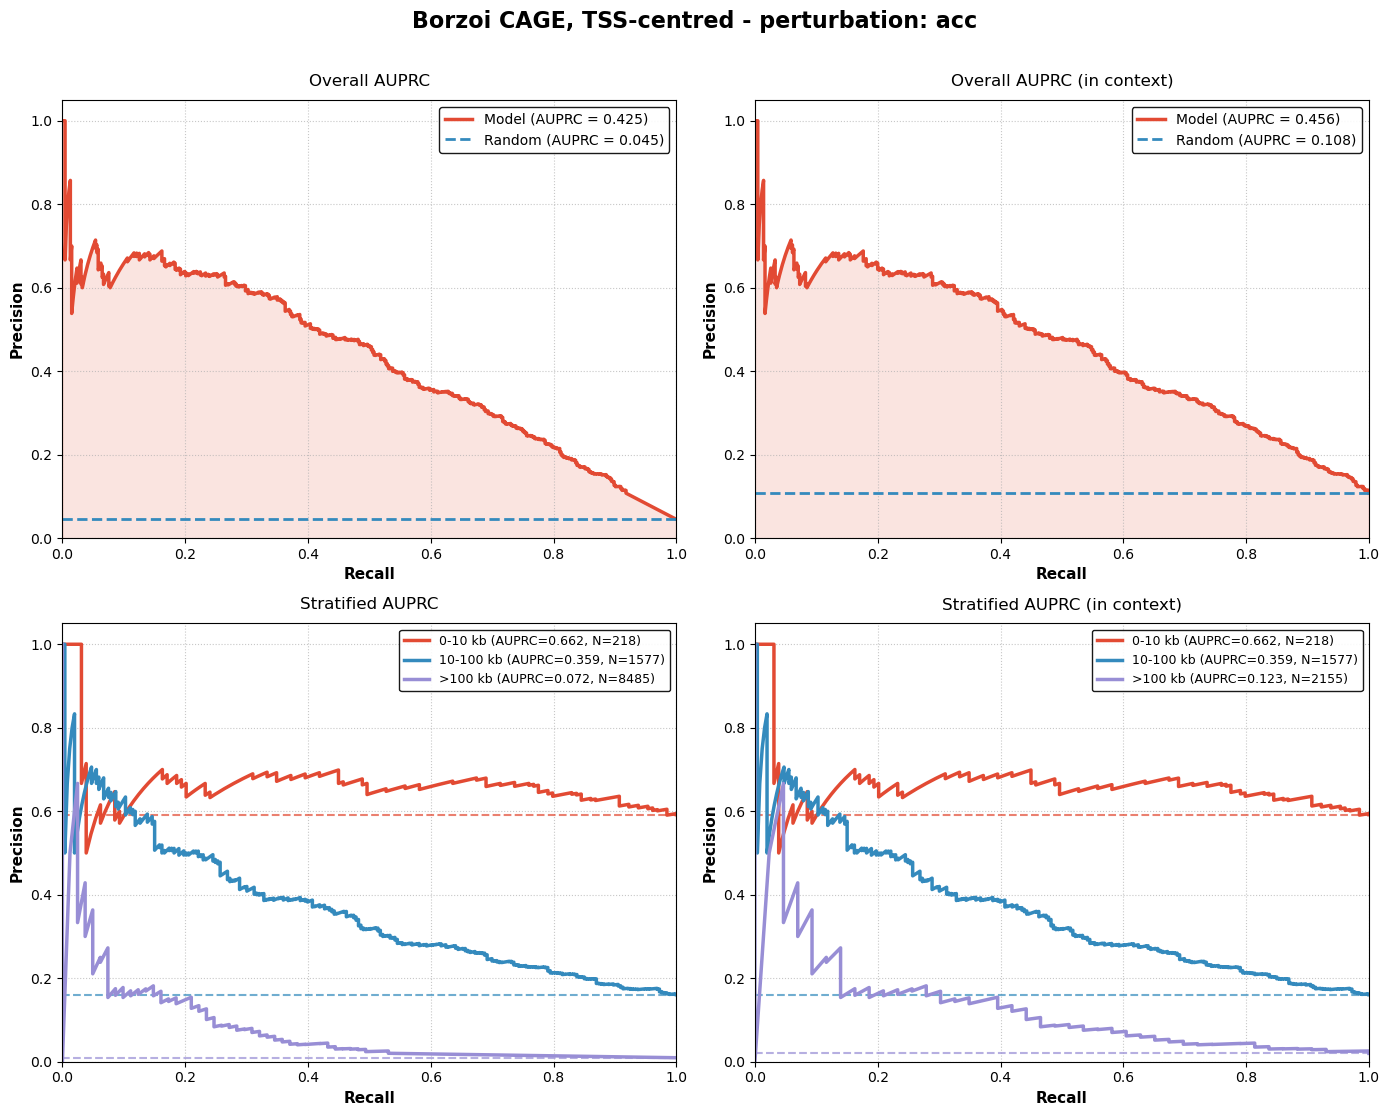

In [8]:
plot_auprc_2x2(scores['acc'], in_context, gs_df, distance_vector,
               title='Borzoi CAGE, TSS-centred - perturbation: acc')

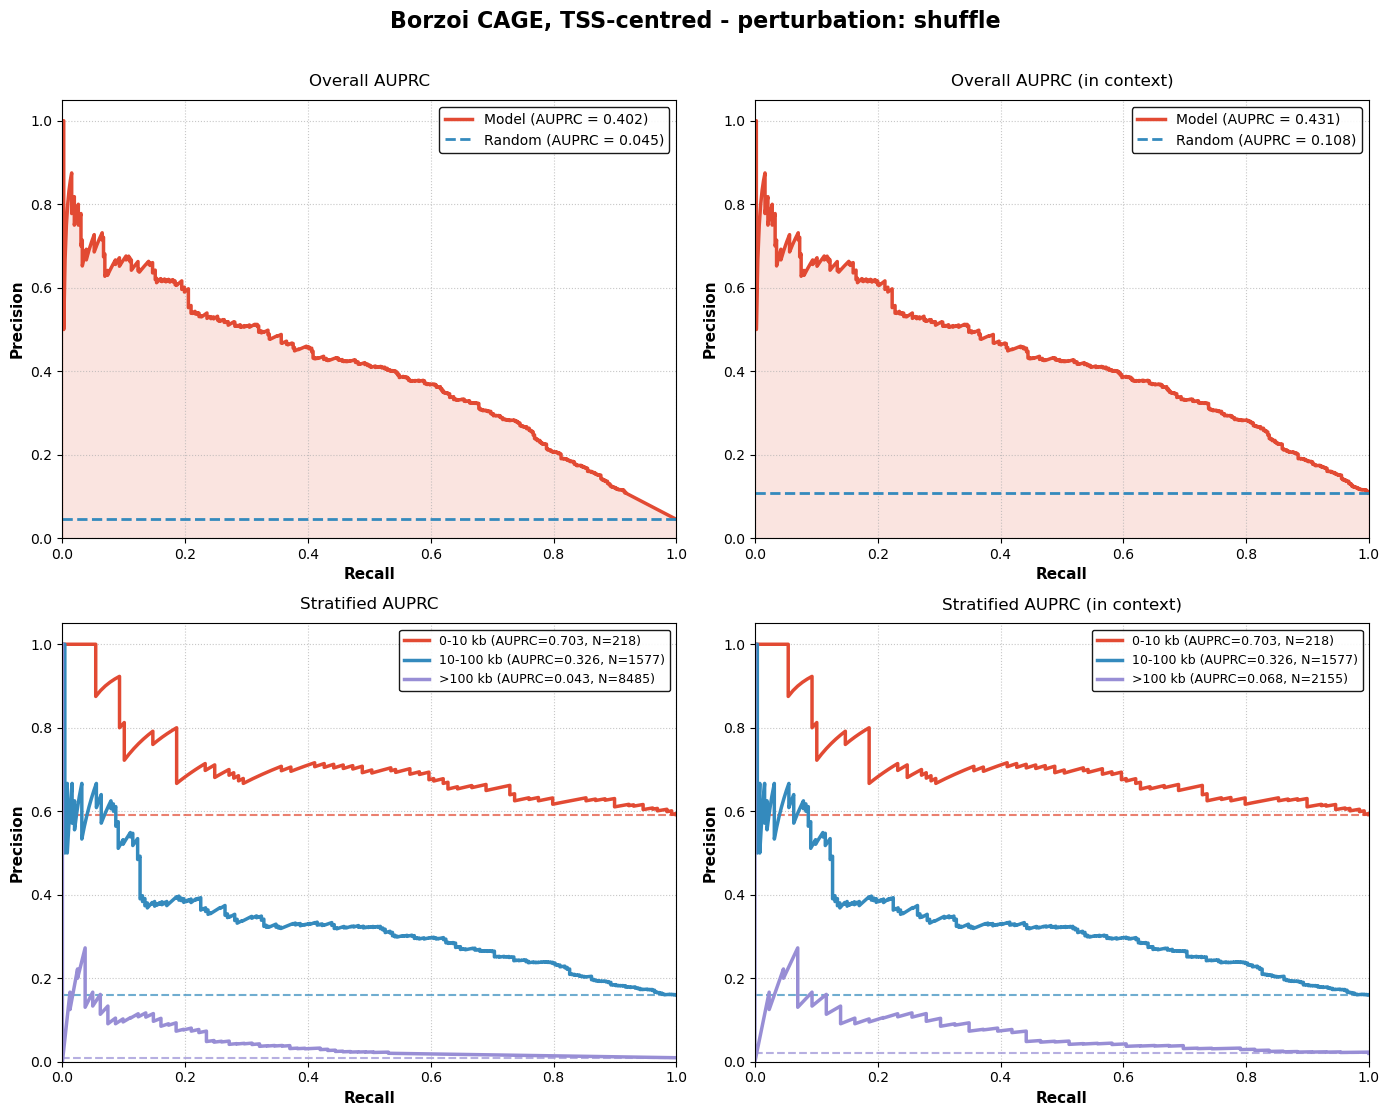

In [9]:
plot_auprc_2x2(scores['shuffle'], in_context, gs_df, distance_vector,
               title='Borzoi CAGE, TSS-centred - perturbation: shuffle')

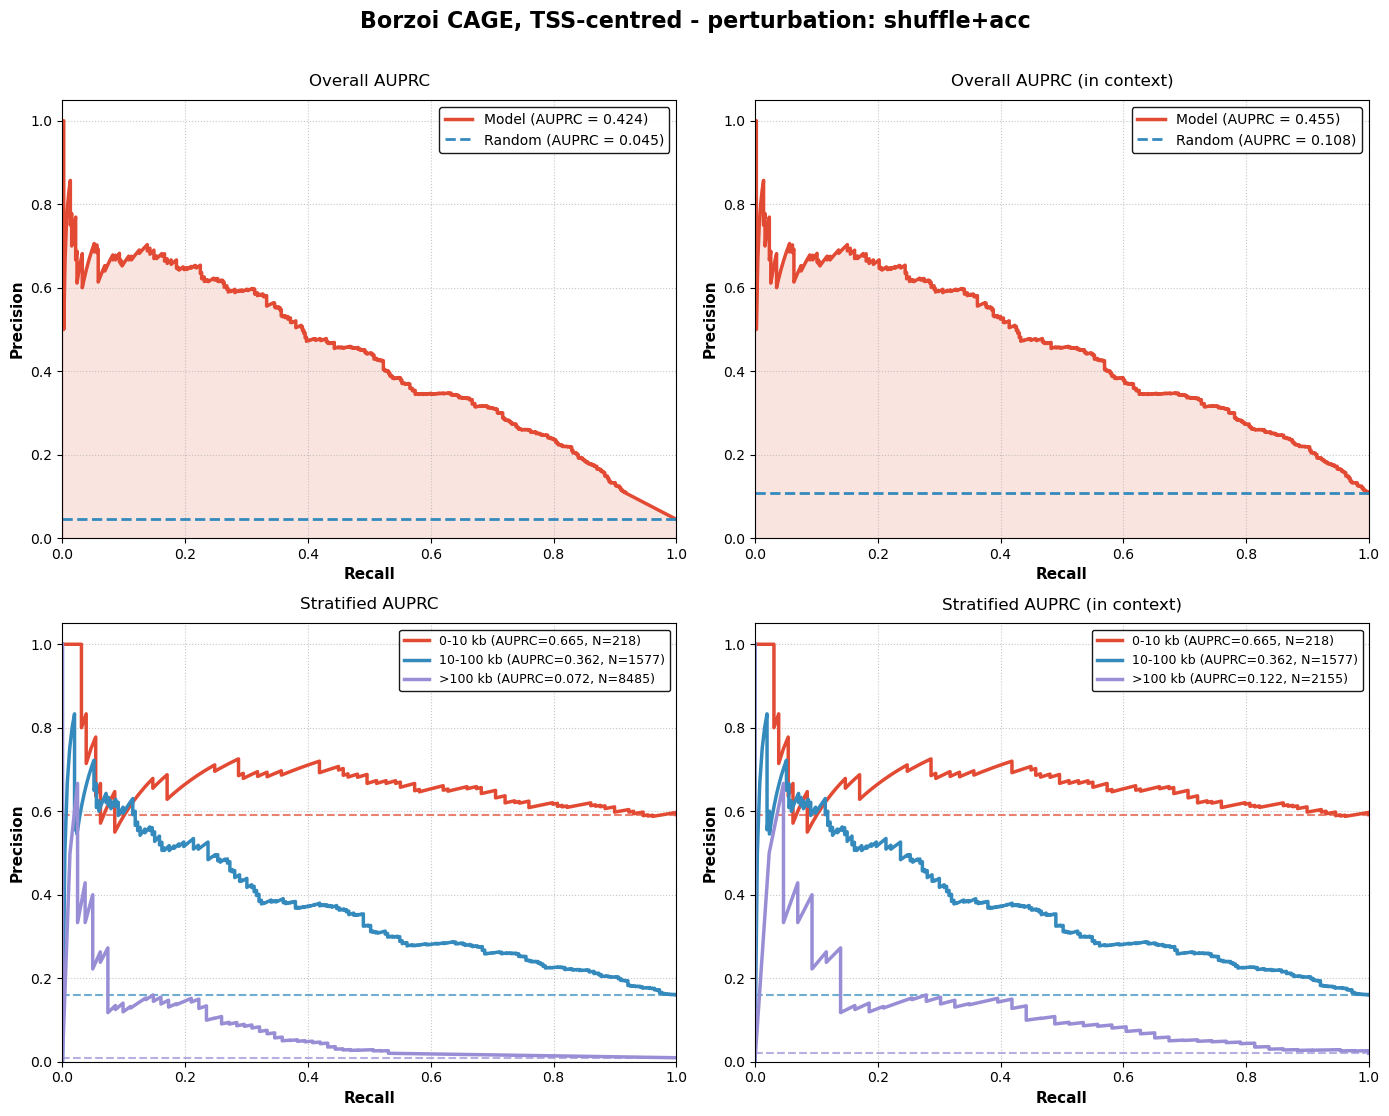

In [10]:
plot_auprc_2x2(scores['shuffle+acc'], in_context, gs_df, distance_vector,
               title='Borzoi CAGE, TSS-centred - perturbation: shuffle+acc')

## Correlation with measured effect size

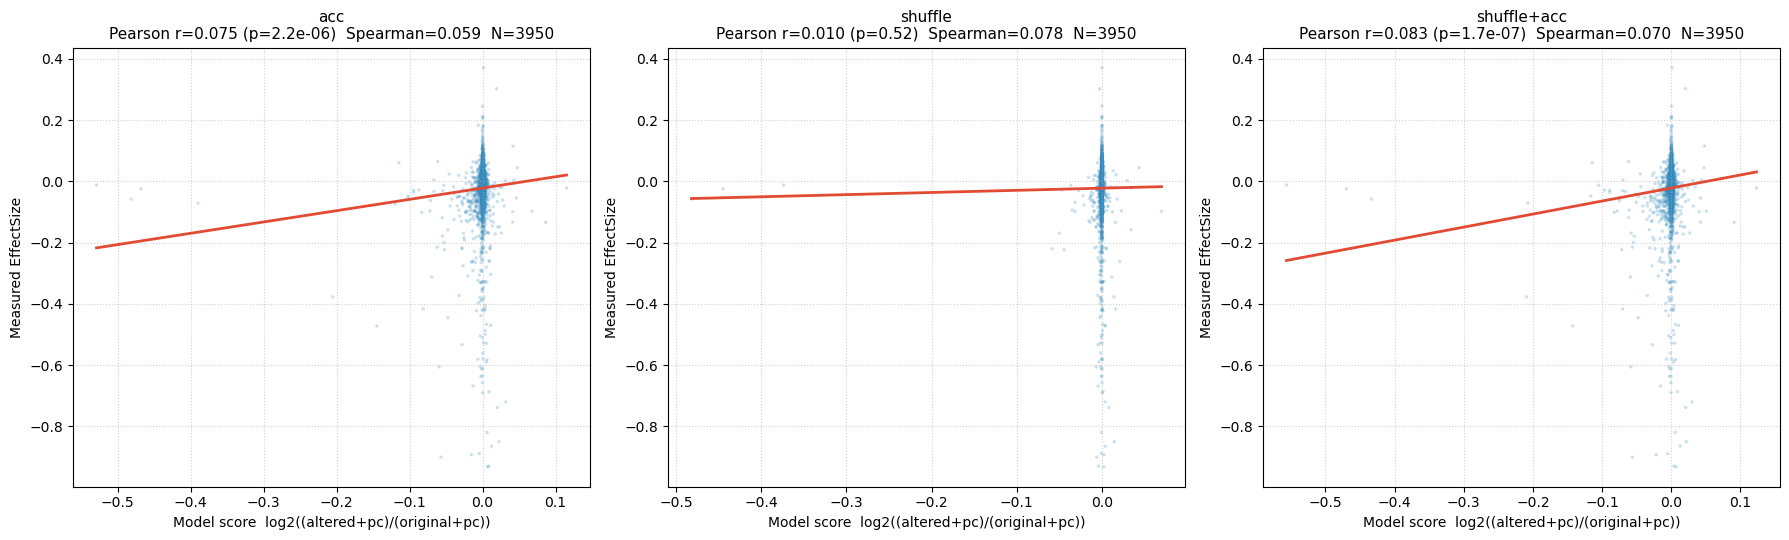

In [11]:
from scipy import stats

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, k in zip(axes, RUNS):
    m = in_context & np.isfinite(scores[k]) & gs_df['EffectSize'].notna().values
    x, y = scores[k][m], gs_df['EffectSize'].values[m]
    r, p = stats.pearsonr(x, y)
    rho, prho = stats.spearmanr(x, y)
    ax.scatter(x, y, s=6, alpha=0.25, color='#348ABD', edgecolors='none')
    if np.ptp(x) > 0:
        b, a = np.polyfit(x, y, 1)
        xs = np.linspace(x.min(), x.max(), 100)
        ax.plot(xs, a + b*xs, color='#E24A33', lw=2)
    ax.set_xlabel('Model score  log2((altered+pc)/(original+pc))', fontsize=10)
    ax.set_ylabel('Measured EffectSize', fontsize=10)
    ax.set_title(f'{k}\nPearson r={r:.3f} (p={p:.2g})  Spearman={rho:.3f}  N={m.sum()}',
                 fontsize=11)
    ax.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout(); plt.show()

## Did 11 shuffles converge?

`_shuffle_std.npy` holds the per-bin standard deviation across the 11 shuffles.
Compared against the size of the WT-vs-shuffle difference itself, this says whether
the shuffle mean is resolved or whether the signal is buried in shuffle noise.

In [12]:
LO, HI = 3072 - mask_len_maintss, 3072 + mask_len_maintss + 1
for k in ['shuffle', 'shuffle+acc']:
    o  = outputs[k]
    sd = np.load(E2G + RUNS[k] + '_shuffle_std.npy', mmap_mode='r')
    wt  = np.asarray(o[:, 0:2, LO:HI]).sum(1).sum(1)
    alt = np.asarray(o[:, 2:4, LO:HI]).sum(1).sum(1)
    s   = np.asarray(sd[:, :, LO:HI]).sum(1).sum(1)
    sem = s / np.sqrt(11)
    m = in_context & (np.abs(wt - alt) > 0)
    ratio = sem[m] / np.abs(wt - alt)[m]
    print(f'{k:12s} median SEM/|WT-shuf| = {np.median(ratio):.3f}   '
          f'frac of pairs where shuffle noise exceeds the effect: {(ratio > 1).mean():.3f}')

shuffle      median SEM/|WT-shuf| = 0.458   frac of pairs where shuffle noise exceeds the effect: 0.242
shuffle+acc  median SEM/|WT-shuf| = 0.036   frac of pairs where shuffle noise exceeds the effect: 0.018


## Sensitivity to the TSS window width

run,acc,shuffle,shuffle+acc
mask_len,,,
3,0.4130,0.3876,0.4132
6,0.4305,0.4035,0.4381
10,0.4485,0.4268,0.4548
18,0.4557,0.4309,0.4549
32,0.4458,0.4280,0.4467
64,0.4417,0.4466,0.4434


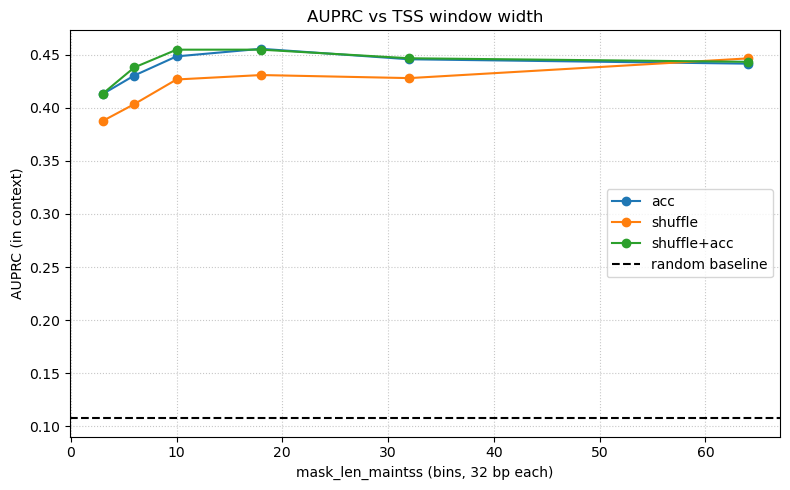

In [13]:
sweep = []
for ml in [3, 6, 10, 18, 32, 64]:
    for k in RUNS:
        sv = make_score_vector(outputs[k], in_context, ml, 0, pseudo_count,
                               assay_type='CAGE', model_type='borzoi')
        yt, ys = y_true_all[in_context], np.abs(sv)[in_context]
        prec, rec, _ = precision_recall_curve(yt, ys)
        sweep.append(dict(mask_len=ml, bp=ml*32, run=k, AUPRC=auc(rec, prec)))
sweep = pd.DataFrame(sweep)
piv = sweep.pivot(index='mask_len', columns='run', values='AUPRC')
display(piv.round(4))

ax = piv.plot(marker='o', figsize=(8, 5))
ax.axhline(y_true_all[in_context].mean(), color='k', ls='--', lw=1.5, label='random baseline')
ax.set_xlabel('mask_len_maintss (bins, 32 bp each)'); ax.set_ylabel('AUPRC (in context)')
ax.set_title('AUPRC vs TSS window width'); ax.grid(True, ls=':', alpha=0.7); ax.legend()
plt.tight_layout(); plt.show()

## Distance-stratified AUPRC vs published methods

Paired barplot in the style of `EP_linking8.ipynb` cell 18. Adds `1/distance` as an
explicit baseline: on this benchmark distance alone is a strong predictor, so any
method has to be read against it rather than against the random baseline.

The literature values are hardcoded from EP_linking8 and are computed on the **full**
benchmark, whereas the three perturbation runs are scored on the **in-context** subset
(3950 pairs whose enhancer falls inside the 524 kb window). The `All` group is
therefore not strictly like-for-like across the two sets of bars; the distance-binned
groups are the meaningful comparison.

In [14]:
import matplotlib as mpl

#hardcoded from EP_linking8.ipynb, full benchmark
values_dict = {
    "E2G extended": [0.756, 0.89, 0.795, 0.346],
    "ABC":          [0.610, 0.790, 0.622, 0.186],
    "Enformer":     [0.490, 0.800, 0.456, 0.020],
    "GraphReg":     [0.420, 0.720, 0.475, 0.139],
    "Cis Mamba":    [0.453, 0.775, 0.478, 0.101],
}

#computed here, in-context pairs only
d_ctx  = np.abs(distance_vector)[in_context]
yt_ctx = y_true_all[in_context]
groups = [
    ("All",            np.ones(len(d_ctx), bool)),
    ("(0, 10]",        d_ctx <= 10_000),
    ("(10, 100]",      (d_ctx > 10_000) & (d_ctx <= 100_000)),
    ("(100, 2,500]",   d_ctx > 100_000),
]

def _aupr(yt, ys):
    prec, rec, _ = precision_recall_curve(yt, ys)
    return auc(rec, prec)

ours = {'1/distance': 1.0 / (d_ctx + 1)}
for k in RUNS:
    ours[k] = np.abs(scores[k])[in_context]

for name, sv in ours.items():
    values_dict[name] = [_aupr(yt_ctx[m], sv[m]) for _, m in groups]

#also report the random baseline per group for context
print('group             N     random')
for (nm, m) in groups:
    print(f'{nm:<15} {m.sum():>5}   {yt_ctx[m].mean():.4f}')
print()
display(pd.DataFrame(values_dict, index=[g[0] for g in groups]).T.round(4))

group             N     random
All              3950   0.1076
(0, 10]           218   0.5917
(10, 100]        1577   0.1604
(100, 2,500]     2155   0.0200



,All,"(0, 10]","(10, 100]","(100, 2,500]"
E2G extended,0.7560,0.8900,0.7950,0.3460
ABC,0.6100,0.7900,0.6220,0.1860
Enformer,0.4900,0.8000,0.4560,0.0200
GraphReg,0.4200,0.7200,0.4750,0.1390
Cis Mamba,0.4530,0.7750,0.4780,0.1010
1/distance,0.4671,0.7143,0.2785,0.0327
acc,0.4557,0.6624,0.3593,0.1232
shuffle,0.4309,0.7029,0.3259,0.0683
shuffle+acc,0.4549,0.6648,0.3624,0.1224


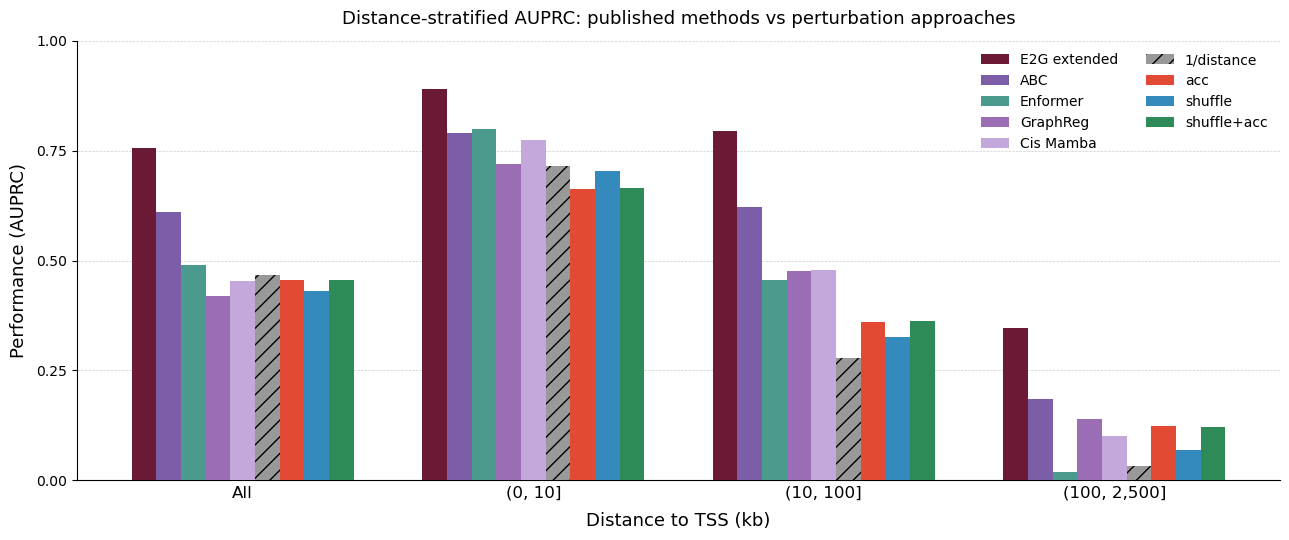

In [15]:
categories = [g[0] for g in groups]
methods = list(values_dict.keys())
#grey-ish for published methods, saturated for the distance baseline and our three runs
colors = ["#6B1A35", "#7B5EA7", "#4A9B8E", "#9B6DB5", "#C4A8DC",
          "#999999", "#E24A33", "#348ABD", "#2E8B57"]

n_categories = len(categories)
n_methods = len(methods)
bar_width = 0.09
group_spacing = 0.25
x = np.arange(n_categories) * (n_methods * bar_width + group_spacing)

fig, ax = plt.subplots(figsize=(13, 5.5))

for i, (method, color) in enumerate(zip(methods, colors)):
    offsets = x + i * bar_width
    hatch = '//' if method == '1/distance' else None
    ax.bar(offsets, values_dict[method], width=bar_width, label=method,
           color=color, linewidth=0, zorder=3, hatch=hatch)

group_centers = x + (n_methods - 1) * bar_width / 2
ax.set_xticks(group_centers)
ax.set_xticklabels(categories, fontsize=12)
ax.set_xlabel("Distance to TSS (kb)", labelpad=8, fontsize=13)
ax.set_ylabel("Performance (AUPRC)", labelpad=6, fontsize=13)
ax.set_ylim(0, 1.0)
ax.set_yticks([0, 0.25, 0.50, 0.75, 1.00])

ax.yaxis.grid(True, linestyle="--", linewidth=0.5, color="#CCCCCC", zorder=0)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="x", length=0, pad=4)
ax.legend(frameon=False, fontsize=10, ncol=2, loc="upper right")
ax.set_title("Distance-stratified AUPRC: published methods vs perturbation approaches",
             fontsize=13, pad=12)

plt.tight_layout()
plt.show()

## Direction of the predicted effect

Every Regulated pair in the benchmark has `EffectSize < 0` (median -0.107), i.e. CRISPRi
always produced a *decrease*. So "actual direction" is constant on those pairs and a
confusion matrix would be degenerate. The informative question is: how often does the
model also predict a decrease, is that above chance, and is it **specific** to the
regulated pairs rather than a global downward bias of the perturbation?

In [16]:
from scipy import stats

es  = gs_df['EffectSize'].values
reg = gs_df['Regulated'].values.astype(bool)

def wilson(k, n, z=1.96):
    p = k / n; d = 1 + z*z/n
    c = (p + z*z/(2*n)) / d
    h = z * np.sqrt(p*(1-p)/n + z*z/(4*n*n)) / d
    return c - h, c + h

dir_stats = {}
for k in RUNS:
    row = {}
    for lab, sub in [('Regulated', ic_reg := in_context & reg),
                     ('Not regulated', in_context & ~reg)]:
        m = sub & np.isfinite(scores[k]) & np.isfinite(es)
        n = int(m.sum()); nd = int((scores[k][m] < 0).sum())
        lo, hi = wilson(nd, n)
        pval = stats.binomtest(nd, n, 0.5, alternative='greater').pvalue
        row[lab] = dict(n=n, n_down=nd, frac=nd/n, lo=lo, hi=hi, p=pval)
    dir_stats[k] = row

print(f'{"arm":<13} {"subset":<15} {"N":>5} {"pred. decrease":>15} {"95% CI":>16} {"binom p":>10}')
for k, row in dir_stats.items():
    for lab, d in row.items():
        print(f'{k:<13} {lab:<15} {d["n"]:>5} {d["frac"]:>14.3f}  [{d["lo"]:.3f}, {d["hi"]:.3f}] {d["p"]:>10.2e}')

arm           subset              N  pred. decrease           95% CI    binom p
acc           Regulated         425          0.534  [0.487, 0.581]   8.72e-02
acc           Not regulated    3525          0.310  [0.295, 0.326]   1.00e+00
shuffle       Regulated         425          0.600  [0.553, 0.645]   2.18e-05
shuffle       Not regulated    3525          0.557  [0.540, 0.573]   9.70e-12
shuffle+acc   Regulated         425          0.562  [0.515, 0.609]   5.78e-03
shuffle+acc   Not regulated    3525          0.316  [0.301, 0.332]   1.00e+00


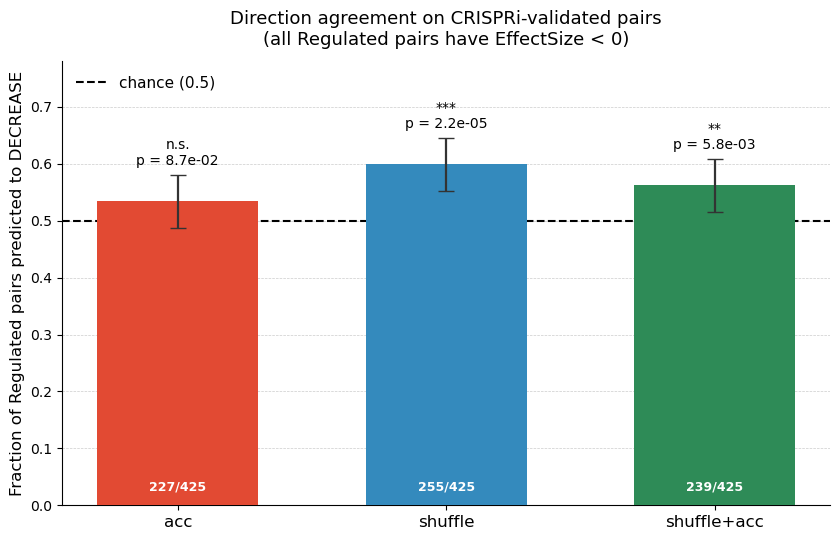

In [17]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))

arms = list(RUNS)
xpos = np.arange(len(arms))
fr  = [dir_stats[k]['Regulated']['frac'] for k in arms]
lo  = [dir_stats[k]['Regulated']['lo']   for k in arms]
hi  = [dir_stats[k]['Regulated']['hi']   for k in arms]
err = np.array([np.array(fr)-np.array(lo), np.array(hi)-np.array(fr)])
cols = ['#E24A33', '#348ABD', '#2E8B57']

bars = ax.bar(xpos, fr, yerr=err, capsize=6, color=cols, width=0.6, zorder=3,
              error_kw=dict(lw=1.6, ecolor='#333333'))
ax.axhline(0.5, color='k', ls='--', lw=1.5, zorder=2, label='chance (0.5)')

for i, k in enumerate(arms):
    d = dir_stats[k]['Regulated']
    star = 'n.s.' if d['p'] > .05 else ('*' if d['p'] > .01 else ('**' if d['p'] > 1e-3 else '***'))
    ax.text(i, d['hi'] + 0.012, f"{star}\np = {d['p']:.1e}", ha='center', va='bottom', fontsize=10)
    ax.text(i, 0.02, f"{d['n_down']}/{d['n']}", ha='center', va='bottom', fontsize=9,
            color='white', fontweight='bold')

ax.set_xticks(xpos); ax.set_xticklabels(arms, fontsize=12)
ax.set_ylabel('Fraction of Regulated pairs predicted to DECREASE', fontsize=12)
ax.set_title('Direction agreement on CRISPRi-validated pairs\n(all Regulated pairs have EffectSize < 0)',
             fontsize=13, pad=12)
ax.set_ylim(0, 0.78)
ax.yaxis.grid(True, ls='--', lw=.5, color='#CCCCCC', zorder=0); ax.set_axisbelow(True)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.legend(frameon=False, fontsize=11, loc='upper left')
plt.tight_layout(); plt.show()


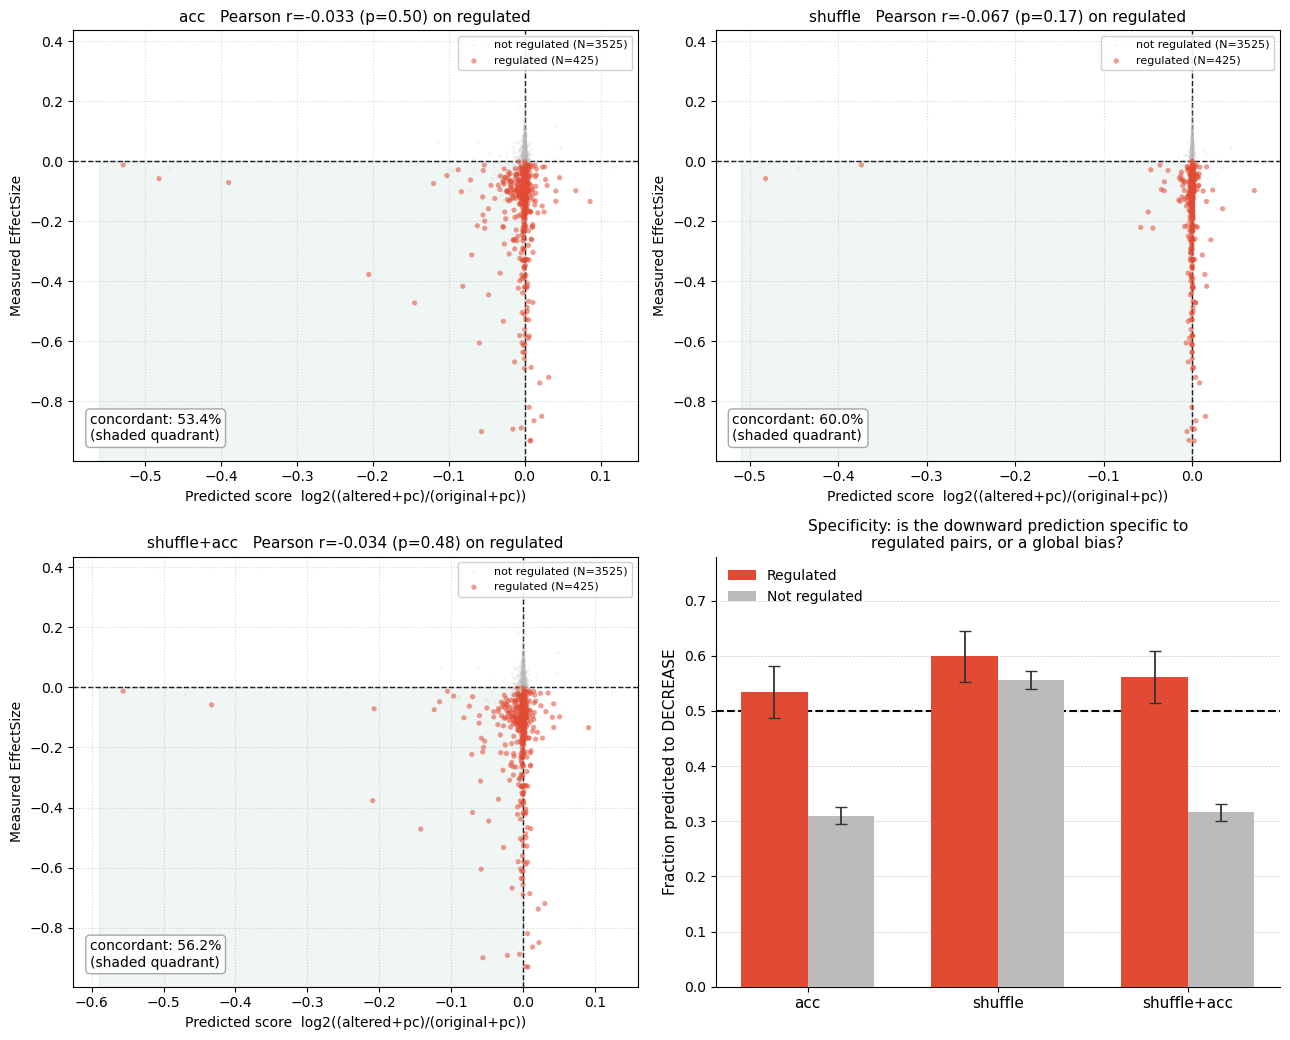

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10.5))

#three scatter panels: predicted score vs measured EffectSize, Regulated pairs
for ax, k in zip(axes.flat[:3], RUNS):
    m  = in_context & reg & np.isfinite(scores[k]) & np.isfinite(es)
    mn = in_context & ~reg & np.isfinite(scores[k]) & np.isfinite(es)
    ax.scatter(scores[k][mn], es[mn], s=5, alpha=0.15, color='#BBBBBB',
               edgecolors='none', label=f'not regulated (N={mn.sum()})', zorder=2)
    ax.scatter(scores[k][m],  es[m],  s=14, alpha=0.55, color='#E24A33',
               edgecolors='none', label=f'regulated (N={m.sum()})', zorder=3)
    ax.axvline(0, color='k', lw=1, ls='--', zorder=1)
    ax.axhline(0, color='k', lw=1, ls='--', zorder=1)
    #shade the concordant quadrant: predicted decrease AND measured decrease
    xl = ax.get_xlim(); yl = ax.get_ylim()
    ax.axvspan(xl[0], 0, ymin=0, ymax=(0-yl[0])/(yl[1]-yl[0]), color='#2E8B57', alpha=0.07, zorder=0)
    d = dir_stats[k]['Regulated']
    ax.text(0.03, 0.04, f"concordant: {d['frac']*100:.1f}%\n(shaded quadrant)",
            transform=ax.transAxes, fontsize=10, va='bottom',
            bbox=dict(boxstyle='round', fc='white', ec='#999999', alpha=.85))
    r, pv = stats.pearsonr(scores[k][m], es[m])
    ax.set_title(f'{k}   Pearson r={r:+.3f} (p={pv:.2f}) on regulated', fontsize=11)
    ax.set_xlabel('Predicted score  log2((altered+pc)/(original+pc))', fontsize=10)
    ax.set_ylabel('Measured EffectSize', fontsize=10)
    ax.grid(True, ls=':', alpha=.5)
    ax.legend(fontsize=8, loc='upper right', framealpha=.9)

#fourth panel: specificity - is the downward bias specific to regulated pairs?
ax = axes.flat[3]
w = 0.35; xpos = np.arange(len(RUNS))
for j, (lab, col) in enumerate([('Regulated', '#E24A33'), ('Not regulated', '#BBBBBB')]):
    f  = [dir_stats[k][lab]['frac'] for k in RUNS]
    l_ = [dir_stats[k][lab]['lo']   for k in RUNS]
    h_ = [dir_stats[k][lab]['hi']   for k in RUNS]
    e  = np.array([np.array(f)-np.array(l_), np.array(h_)-np.array(f)])
    ax.bar(xpos + (j-0.5)*w, f, yerr=e, width=w, color=col, label=lab, capsize=4,
           zorder=3, error_kw=dict(lw=1.3, ecolor='#333333'))
ax.axhline(0.5, color='k', ls='--', lw=1.5, zorder=2)
ax.set_xticks(xpos); ax.set_xticklabels(list(RUNS), fontsize=11)
ax.set_ylabel('Fraction predicted to DECREASE', fontsize=11)
ax.set_title('Specificity: is the downward prediction specific to\nregulated pairs, or a global bias?', fontsize=11)
ax.set_ylim(0, 0.78)
ax.yaxis.grid(True, ls='--', lw=.5, color='#CCCCCC', zorder=0); ax.set_axisbelow(True)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.legend(frameon=False, fontsize=10, loc='upper left')

plt.tight_layout(); plt.show()


---

# Part 2 - the same analysis for the other models

Everything above is one checkpoint (the caduceus model with a stranded Borzoi CAGE head)
under three perturbations. Part 2 adds the runs that finished after this notebook was
first written, so the perturbation score can be read against both our other heads and the
published sequence models.

| key | what it is | input | output | bins | element perturbable within | arms |
|---|---|---|---|---|---|---|
| `ours-borzoi`   | caduceus + stranded Borzoi CAGE head (`2026-02-25/23-21-56`) | 524 kb | 196 kb | 6144 x 32 bp | +/-262 kb (3950 pairs) | acc, shuffle, shuffle+acc |
| `ours-enformer` | caduceus + unstranded Enformer CAGE head (`2025-08-15/12-23-01`) | 524 kb | 115 kb | 896 x 128 bp | +/-262 kb (3950 pairs) | acc, shuffle, shuffle+acc |
| `ours-striped`  | striped hydra, stranded CAGE head (`2026-05-13/12-20-24`, step 19250) | 2 Mb | 1 Mb | 32768 x 32 bp | +/-1 Mb (9732 pairs) | acc, shuffle, shuffle+acc |
| `Borzoi`        | pretrained Borzoi, ENCODE CAGE:K562 +/- (units 872/873) | 524 kb | 196 kb | 6144 x 32 bp | +/-262 kb (3950 pairs) | shuffle |
| `Enformer`      | pretrained Enformer, CAGE:K562 (track 5111) | 197 kb real seq in a 393 kb zero-padded input | 115 kb | 896 x 128 bp | +/-98 kb (1763 pairs) | shuffle |
| `AlphaGenome`   | AlphaGenome API, hCAGE `EFO:0002067` +/-, ALL_FOLDS | 1 Mb | 196 kb | 6144 x 32 bp | +/-524 kb (6624 pairs) | shuffle |

All 15 runs use the same 10280-row filtered benchmark in the same order, `--seed 0`,
`--dist_additional_shuffle 100`, `n_shuffles=11`, and (per the arm scripts) bit-identical
dinucleotide shuffles, so the only thing that differs between arms of the same model is
the perturbation and between models is the model.

### Three things to keep straight

1. **`in_context` is not the same set across models.** It is judged against each model's
   *input* window, so it ranges from 1763 pairs (Enformer) to 9732 (striped). Every table
   below therefore reports the subset it was computed on: `own` = that run's own
   in-context set, `262kb` = the 3950-pair Borzoi reach, `common` = the 1763 pairs every
   run can perturb.
2. **The `all` (10280-pair) column is not a fair comparison.** Out-of-window pairs get
   score 0 and sort to the bottom of the `|score|` ranking, which is the correct answer
   for distance reasons, so a model with a wider input window is credited for pairs it
   never actually looked at. Read `common`, or `262kb`, not `all`.
3. **The scored region is the same for all of them.** Every run is TSS-centred with the
   TSS on the middle output bin (verified below), and the window is specified in **bp**,
   not bins, so the 32 bp and 128 bp models integrate the same physical region.

In [19]:
import zarr

#128 bins each side of the TSS bin: 4096 bp for the 32 bp models, 16 kb for the 128 bp ones,
#wider than any window swept below. Slicing this slab out once turns the 5.4 GB striped
#arrays into an 85 MB in-memory array and makes everything downstream uniform and fast.
CAP = 128

#rows: 2 -> [before, after] (unstranded CAGE head), 4 -> [before+, before-, after+, after-]
MODELS = {
    'ours-borzoi':   dict(bin=32,  reach=262144,  kind='joint', arms={
        'acc':         'k562_stranded_borzoi_cage_tss_centered',
        'shuffle':     'k562_stranded_borzoi_cage_tss_centered_dinuc',
        'shuffle+acc': 'k562_stranded_borzoi_cage_tss_centered_dinuc_acc'}),
    'ours-enformer': dict(bin=128, reach=262144,  kind='joint', arms={
        'acc':         'k562_unstranded_enformer_tss_centered',
        'shuffle':     'k562_unstranded_enformer_tss_centered_dinuc',
        'shuffle+acc': 'k562_unstranded_enformer_tss_centered_dinuc_acc'}),
    'ours-striped':  dict(bin=32,  reach=1048576, kind='joint', arms={
        'acc':         'k562_striped_tss_centered',
        'shuffle':     'k562_striped_tss_centered_dinuc',
        'shuffle+acc': 'k562_striped_tss_centered_dinuc_acc'}),
    'Borzoi':        dict(bin=32,  reach=262144,  kind='seq',   arms={
        'shuffle':     'k562_borzoi_cage_tss_centered_dinuc'}),
    'Enformer':      dict(bin=128, reach=98304,   kind='seq',   arms={
        'shuffle':     'k562_enformer_e2g_tss_centered_dinuc'}),
    'AlphaGenome':   dict(bin=32,  reach=524288,  kind='seq',   arms={
        'shuffle':     'k562_alphagenome_e2g_tss_centered_dinuc.zarr'}),
}

ARM_ORDER   = ['acc', 'shuffle', 'shuffle+acc']
MODEL_ORDER = list(MODELS)


def load_slab(base):
    '''Central +-CAP bins around the TSS bin, plus the in_context / shuffled sidecars.

    The AlphaGenome arm is a resumable zarr group rather than an npy triple, but the
    array it holds has exactly the borzoi row layout and bin grid.'''
    if base.endswith('.zarr'):
        z = zarr.open(E2G + base, mode='r')
        assert z['done'][:].all(), 'zarr has unfinished rows'
        c = z['preds'].shape[-1] // 2
        return (z['preds'][:, :, c - CAP:c + CAP + 1].astype(np.float64),
                z['in_context'][:], z['shuffled'][:])
    a  = np.load(E2G + base + '.npy', mmap_mode='r')
    c  = a.shape[-1] // 2
    sl = np.asarray(a[:, :, c - CAP:c + CAP + 1]).astype(np.float64)
    ic = np.load(E2G + base + '_in_context.npy')
    try:
        sh = np.load(E2G + base + '_shuffled.npy')
    except FileNotFoundError:
        sh = None  # the acc arms predate the shuffled sidecar
    return sl, ic, sh


In [20]:
slabs, ctx2, shuf2 = {}, {}, {}
rows = []
for m in MODEL_ORDER:
    for arm in ARM_ORDER:
        if arm not in MODELS[m]['arms']:
            continue
        sl, ic, sh = load_slab(MODELS[m]['arms'][arm])
        assert len(sl) == len(gs_df), f'{m}/{arm} has {len(sl)} rows, benchmark has {len(gs_df)}'
        slabs[(m, arm)], ctx2[(m, arm)], shuf2[(m, arm)] = sl, ic, sh
        rows.append(dict(model=m, arm=arm, rows=sl.shape[1], bin_bp=MODELS[m]['bin'],
                         reach_kb=MODELS[m]['reach'] // 1000, in_context=int(ic.sum()),
                         shuffled='-' if sh is None else int(sh.sum())))
display(pd.DataFrame(rows))

#every arm of a given model must agree on in_context, otherwise the arms are not paired
for m in MODEL_ORDER:
    ks = [k for k in ctx2 if k[0] == m]
    assert all(np.array_equal(ctx2[ks[0]], ctx2[k]) for k in ks), f'{m}: in_context differs between arms'

common_ctx = np.ones(len(gs_df), bool)
for k in ctx2:
    common_ctx &= ctx2[k]
reach262 = ctx2[('ours-borzoi', 'acc')]        #3950 pairs, the Borzoi / ours-borzoi reach
reach262_models = [m for m in MODEL_ORDER if MODELS[m]['reach'] >= 262144]

y_true_all = gs_df['Regulated'].astype(int).values
print(f'common in-context across all 15 runs: {common_ctx.sum()}  (positives {y_true_all[common_ctx].mean():.4f})')
print(f'262 kb reach subset:                  {reach262.sum()}  (positives {y_true_all[reach262].mean():.4f})')
print(f'full benchmark:                       {len(gs_df)}  (positives {y_true_all.mean():.4f})')

,model,arm,rows,bin_bp,reach_kb,in_context,shuffled
0,ours-borzoi,acc,4,32,262,3950,-
1,ours-borzoi,shuffle,4,32,262,3950,3950
2,ours-borzoi,shuffle+acc,4,32,262,3950,3950
3,ours-enformer,acc,2,128,262,3950,-
4,ours-enformer,shuffle,2,128,262,3950,3950
5,ours-enformer,shuffle+acc,2,128,262,3950,3950
6,ours-striped,acc,4,32,1048,9732,-
7,ours-striped,shuffle,4,32,1048,9732,9732
8,ours-striped,shuffle+acc,4,32,1048,9732,9732
9,Borzoi,shuffle,4,32,262,3950,3950


common in-context across all 15 runs: 1763  (positives 0.2167)
262 kb reach subset:                  3950  (positives 0.1076)
full benchmark:                       10280  (positives 0.0450)


## Scoring, in bp instead of bins

`make_score_vector` above hardcodes `size`/`bin_size` per `model_type` and loops in python
over 10280 rows, which is fine for three runs of one model but not for fifteen runs of
six geometries (the striped head emits 32768 bins, which that function has no branch for).

`score_slab` is the same score - `log2((altered + pc) / (original + pc))` summed over a
window centred on the TSS bin, zero for out-of-window pairs - vectorised over the compact
slab, with the window given in **bp** so it converts to 18 bins for a 32 bp model and
5 bins for a 128 bp one. `mask_len_alttss` is dropped because it is 0 everywhere in this
notebook. The cell asserts the two agree to floating point on the arm Part 1 used.

In [21]:
strand_arr = gs_df['ensg_id'].map(lambda e: tss_dict[e]['strand']).values
HALF_BP = mask_len_maintss * 32   #576 bp, the Part 1 window, now expressed in bp


def score_slab(slab, in_context, bin_size, half_bp, pseudo_count=1e-2):
    '''log2 ratio over a +-half_bp window on the centre bin. Out-of-window pairs score 0.'''
    hb = int(round(half_bp / bin_size))
    lo, hi = CAP - hb, CAP + hb + 1
    n_rows = slab.shape[1]
    if n_rows == 4:
        og = np.where(strand_arr == '+', 0, 1)
        alt = og + 2
    else:
        og = np.zeros(len(slab), dtype=int)
        alt = og + 1
    i = np.arange(len(slab))
    original = slab[i, og,  lo:hi].sum(1)
    altered  = slab[i, alt, lo:hi].sum(1)
    s = np.log2((altered + pseudo_count) / (original + pseudo_count))
    s[~in_context] = 0.0
    return s


#parity with Part 1: same numbers, from a different code path
_check = score_slab(slabs[('ours-borzoi', 'acc')], ctx2[('ours-borzoi', 'acc')], 32, HALF_BP)
_ref   = make_score_vector(np.load(E2G + RUNS['acc'] + '.npy', mmap_mode='r'), in_context,
                           mask_len_maintss, 0, pseudo_count, assay_type='CAGE', model_type='borzoi')
print('max |score_slab - make_score_vector| on ours-borzoi/acc:', np.abs(_check - _ref).max())
assert np.abs(_check - _ref).max() < 1e-9

#and the TSS really is on the centre bin for every geometry: peak of the mean WT profile
print('\nWT profile argmax relative to the centre bin (should be 0, or 1 bin for the 128 bp heads):')
for m in MODEL_ORDER:
    k = (m, 'shuffle')
    sl, ic = slabs[k], ctx2[k]
    nr = sl.shape[1]
    prof = (sl[ic][:, :2].sum(1) if nr == 4 else sl[ic][:, 0]).mean(0)
    off = int(prof.argmax()) - CAP
    print(f'  {m:14s} {off:+3d} bins ({off * MODELS[m]["bin"]:+6d} bp), peak/median = {prof.max() / np.median(prof):5.1f}')

max |score_slab - make_score_vector| on ours-borzoi/acc: 6.406279586673724e-16

WT profile argmax relative to the centre bin (should be 0, or 1 bin for the 128 bp heads):
  ours-borzoi     +0 bins (    +0 bp), peak/median =  96.2
  ours-enformer   -1 bins (  -128 bp), peak/median = 156.9
  ours-striped    +0 bins (    +0 bp), peak/median = 309.6
  Borzoi          +0 bins (    +0 bp), peak/median =  68.2
  Enformer        +0 bins (    +0 bp), peak/median = 129.0
  AlphaGenome     +0 bins (    +0 bp), peak/median = 742.9


## AUPRC, all 15 runs, on three explicit subsets

### The metric: `average_precision_score`, not `auc(recall, precision)`

Part 1 (and `EP_linking4`/`EP_linking8`) computes AUPRC as `auc(recall, precision)` on the
output of `precision_recall_curve`. That trapezoid-integrates a PR curve, and PR curves
must not be linearly interpolated: a block of **tied** scores collapses to one threshold,
and the trapezoid drawn across it invents precision that no operating point achieves. The
degenerate case is the whole stratum tied, where it returns `(baseline + 1) / 2` - about
**0.5 regardless of the data**. Part 2 has large tied blocks by construction, because every
out-of-window pair is assigned score 0, so this matters here in a way it did not in Part 1.

`average_precision_score` is the step-wise sum `sum_n (R_n - R_{n-1}) * P_n`, which does no
interpolation and returns exactly the baseline for an all-tied score. Part 2 uses it
throughout, and reports the trapezoid value alongside so the two conventions can be
compared. For runs without a big tied block the two agree to <0.005, so nothing in Part 1
changes; the cell after next shows where they diverge.

In [22]:
from sklearn.metrics import average_precision_score

sc2 = {k: score_slab(slabs[k], ctx2[k], MODELS[k[0]]['bin'], HALF_BP) for k in slabs}

ALL_PAIRS = np.ones(len(gs_df), bool)


def aupr(mask, s):
    '''Average precision: step-wise, no interpolation across tied scores.'''
    return average_precision_score(y_true_all[mask], np.abs(s)[mask])


def aupr_trap(mask, s):
    '''The auc(recall, precision) convention used in Part 1, kept for comparison only.'''
    prec, rec, _ = precision_recall_curve(y_true_all[mask], np.abs(s)[mask])
    return auc(rec, prec)


rows = []
for k in sc2:
    m, arm = k
    own = ctx2[k]
    rows.append(dict(
        model=m, arm=arm, kind=MODELS[m]['kind'],
        N_own=int(own.sum()), AP_own=aupr(own, sc2[k]),
        AP_262kb=aupr(reach262, sc2[k]) if MODELS[m]['reach'] >= 262144 else np.nan,
        AP_common=aupr(common_ctx, sc2[k]),
        AP_all=aupr(ALL_PAIRS, sc2[k]),
        trap_own=aupr_trap(own, sc2[k]),
        trap_all=aupr_trap(ALL_PAIRS, sc2[k]),
    ))
dist_score = 1.0 / (np.abs(distance_vector) + 1)
rows.append(dict(model='1/distance', arm='-', kind='baseline', N_own=len(gs_df),
                 AP_own=aupr(ALL_PAIRS, dist_score), AP_262kb=aupr(reach262, dist_score),
                 AP_common=aupr(common_ctx, dist_score), AP_all=aupr(ALL_PAIRS, dist_score),
                 trap_own=aupr_trap(ALL_PAIRS, dist_score), trap_all=aupr_trap(ALL_PAIRS, dist_score)))
rows.append(dict(model='random', arm='-', kind='baseline', N_own=len(gs_df),
                 AP_own=y_true_all.mean(), AP_262kb=y_true_all[reach262].mean(),
                 AP_common=y_true_all[common_ctx].mean(), AP_all=y_true_all.mean(),
                 trap_own=np.nan, trap_all=np.nan))

summary2 = pd.DataFrame(rows)
display(summary2.round(4))
print('subset sizes: own = per-run in_context, 262kb =', int(reach262.sum()),
      ', common =', int(common_ctx.sum()), ', all =', len(gs_df))
print('trap_* are the Part 1 auc(recall, precision) convention. Note trap_all vs AP_all for')
print('Enformer: on the full benchmark 8517/10280 of its pairs are tied at score 0, and the')
print('trapezoid credits it for them. AP_all does not. See caveat 2 and the next cell.')

,model,arm,kind,N_own,AP_own,AP_262kb,AP_common,AP_all,trap_own,trap_all
0,ours-borzoi,acc,joint,3950,0.4570,0.4570,0.4951,0.4232,0.4557,0.4245
1,ours-borzoi,shuffle,joint,3950,0.4324,0.4324,0.4764,0.4006,0.4309,0.4018
2,ours-borzoi,shuffle+acc,joint,3950,0.4564,0.4564,0.4935,0.4226,0.4549,0.4238
3,ours-enformer,acc,joint,3950,0.3810,0.3810,0.4223,0.3534,0.3799,0.3550
4,ours-enformer,shuffle,joint,3950,0.3640,0.3640,0.4062,0.3378,0.3630,0.3395
5,ours-enformer,shuffle+acc,joint,3950,0.3793,0.3793,0.4192,0.3519,0.3782,0.3534
6,ours-striped,acc,joint,9732,0.4395,0.4970,0.5702,0.4352,0.4386,0.4344
7,ours-striped,shuffle,joint,9732,0.3608,0.4281,0.5118,0.3574,0.3589,0.3555
8,ours-striped,shuffle+acc,joint,9732,0.4430,0.5004,0.5723,0.4387,0.4421,0.4378
9,Borzoi,shuffle,seq,3950,0.4802,0.4802,0.5418,0.4445,0.4795,0.4464


subset sizes: own = per-run in_context, 262kb = 3950 , common = 1763 , all = 10280
trap_* are the Part 1 auc(recall, precision) convention. Note trap_all vs AP_all for
Enformer: on the full benchmark 8517/10280 of its pairs are tied at score 0, and the
trapezoid credits it for them. AP_all does not. See caveat 2 and the next cell.


### Where the two conventions diverge, and why the distal bars needed fixing

A worked example rather than an assertion. Take a score that is **constant** on a stratum -
it ranks nothing, so the only defensible AUPRC is the positive rate. The pretrained
Enformer is exactly this case beyond 100 kb: its input reaches +/-98 kb, so all 8485 pairs
in the `(100, 2500]` stratum are out of window, all are assigned score 0, and none of the
81 distal positives is reachable.

In [23]:
far = np.abs(distance_vector) > 100_000
const = np.zeros(len(gs_df))
enf = sc2[('Enformer', 'shuffle')]

print(f'>100 kb stratum: N={far.sum()}, positives={y_true_all[far].sum()}, '
      f'baseline={y_true_all[far].mean():.4f}')
print(f'distinct |score| values Enformer takes there: {len(np.unique(np.abs(enf)[far]))}')
_enf_reach = int(((y_true_all == 1) & far & ctx2[('Enformer', 'shuffle')]).sum())
print(f'distal positives reachable by Enformer:       {_enf_reach} of {y_true_all[far].sum()}')
print()
print(f'{"":34s}{"auc(rec,prec)":>15s}{"average_precision":>19s}')
print(f'{"constant score (ranks nothing)":34s}{aupr_trap(far, const):>15.4f}{aupr(far, const):>19.4f}')
print(f'{"Enformer, >100 kb":34s}{aupr_trap(far, enf):>15.4f}{aupr(far, enf):>19.4f}')
print(f'{"random baseline":34s}{"-":>15s}{y_true_all[far].mean():>19.4f}')
print()
print('The trapezoid returns ~(baseline+1)/2 = 0.505 for a score that carries no information.')
print('That is the number that would have appeared as an Enformer distal bar. AP returns the')
print('baseline, 0.0095, which is the right answer.')
print()
print('how much of each stratum is tied at score 0 (out of window), per model:')
tie_rows = []
for m in MODEL_ORDER:
    k = (m, 'shuffle')
    r = {'model': m, 'reach_kb': MODELS[m]['reach'] // 1000}
    for lab, msk in [('All', ALL_PAIRS), ('(0,10]', np.abs(distance_vector) <= 10_000),
                     ('(10,100]', (np.abs(distance_vector) > 10_000) & (np.abs(distance_vector) <= 100_000)),
                     ('(100,2500]', far)]:
        r[lab] = f'{int((msk & ~ctx2[k]).sum())}/{int(msk.sum())}'
    r['distal pos. reachable'] = f'{int(((y_true_all == 1) & far & ctx2[k]).sum())}/{int(((y_true_all == 1) & far).sum())}'
    tie_rows.append(r)
display(pd.DataFrame(tie_rows))

>100 kb stratum: N=8485, positives=81, baseline=0.0095
distinct |score| values Enformer takes there: 1
distal positives reachable by Enformer:       0 of 81

                                    auc(rec,prec)  average_precision
constant score (ranks nothing)             0.5048             0.0095
Enformer, >100 kb                          0.5048             0.0095
random baseline                                 -             0.0095

The trapezoid returns ~(baseline+1)/2 = 0.505 for a score that carries no information.
That is the number that would have appeared as an Enformer distal bar. AP returns the
baseline, 0.0095, which is the right answer.

how much of each stratum is tied at score 0 (out of window), per model:


,model,reach_kb,All,"(0,10]","(10,100]","(100,2500]",distal pos. reachable
0,ours-borzoi,262,6330/10280,0/218,0/1577,6330/8485,43/81
1,ours-enformer,262,6330/10280,0/218,0/1577,6330/8485,43/81
2,ours-striped,1048,548/10280,0/218,0/1577,548/8485,76/81
3,Borzoi,262,6330/10280,0/218,0/1577,6330/8485,43/81
4,Enformer,98,8517/10280,0/218,32/1577,8485/8485,0/81
5,AlphaGenome,524,3656/10280,0/218,0/1577,3656/8485,64/81


### Like-for-like: every run on the 1763 pairs all six models can perturb

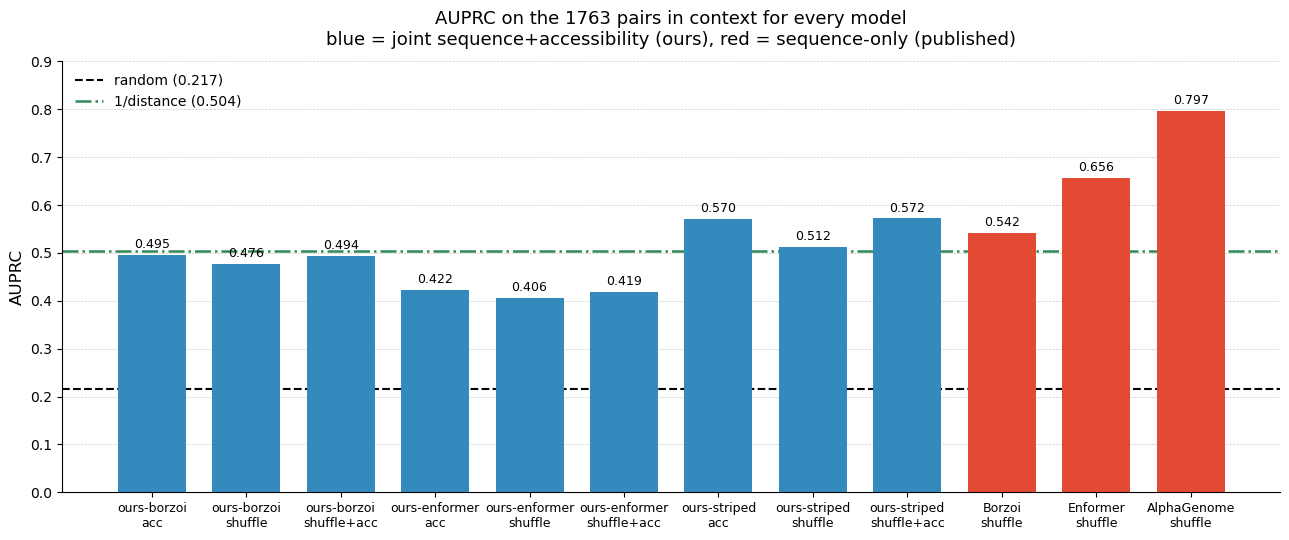

In [24]:
order = [k for k in sc2]
labels = [f'{m}\n{arm}' for m, arm in order]
vals   = [aupr(common_ctx, sc2[k]) for k in order]
kinds  = [MODELS[k[0]]['kind'] for k in order]
cols   = ['#348ABD' if k == 'joint' else '#E24A33' for k in kinds]

fig, ax = plt.subplots(figsize=(13, 5.5))
xs = np.arange(len(order))
ax.bar(xs, vals, color=cols, width=0.72, zorder=3)
ax.axhline(y_true_all[common_ctx].mean(), color='k', ls='--', lw=1.5, zorder=2,
           label=f'random ({y_true_all[common_ctx].mean():.3f})')
ax.axhline(aupr(common_ctx, dist_score), color='#2E8B57', ls='-.', lw=1.8, zorder=2,
           label=f'1/distance ({aupr(common_ctx, dist_score):.3f})')
for x, v in zip(xs, vals):
    ax.text(x, v + 0.008, f'{v:.3f}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(xs)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('AUPRC', fontsize=12)
ax.set_ylim(0, 0.9)
ax.set_title(f'AUPRC on the {int(common_ctx.sum())} pairs in context for every model\n'
             'blue = joint sequence+accessibility (ours), red = sequence-only (published)',
             fontsize=13, pad=12)
ax.yaxis.grid(True, ls='--', lw=.5, color='#CCCCCC', zorder=0); ax.set_axisbelow(True)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.legend(frameon=False, fontsize=10, loc='upper left')
plt.tight_layout(); plt.show()

### Distance-stratified vs published methods, on the *literature's* strata

**This replaces an earlier version of this panel that was wrong in two ways**, both of
which inflated our bars against the published numbers - most visibly making AlphaGenome
look like it beat E2G-extended at distal elements, which it does not.

1. **Wrong stratum.** The earlier panel binned `(100, 262]` on the 3950-pair 262 kb subset.
   The published values are `(100, 2500]` on the **full** benchmark. Those are not the same
   slice: 2155 pairs at a 2.00% positive rate versus 8485 pairs at 0.95%. Restricting to
   the pairs a 524 kb model can reach throws away the hardest two thirds of the distal
   stratum and roughly doubles the baseline, so it roughly doubles the achievable AUPRC.
2. **Wrong metric for tied scores.** With `auc(recall, precision)`, the out-of-window pairs
   that dominate the distal stratum are credited rather than ignored - see the cell above.

So this panel is now computed on the **full 10280-pair benchmark** with the literature's own
bins and `average_precision_score`, which is what the E2G/ABC numbers hardcoded from
`EP_linking8` represent. A model with a narrow input window is now correctly penalised in the
distal bin for the positives it cannot see, rather than rewarded for tying them.

The honest read at distal: **AlphaGenome 0.357 vs E2G-extended 0.346 is a tie**, not a win,
and AlphaGenome is *below* E2G-extended in every other bin. The published methods use
measured K562 assays (ATAC, Hi-C, CTCF) as input; the sequence models here see sequence only,
so parity at distal is the interesting result, and claiming more than parity was an artifact.

### Provenance of the published bars, and what AlphaGenome actually claims

**The five literature values are unverified.** They are hardcoded in `EP_linking8.ipynb`
cell 18 with no citation, no stated metric, and no stated pair set (next to a commented-out
plain `E2G` row and a `Cis Mamba` row, so they were most likely digitised from that paper's
figure). They are *not* recomputed on the 10280 pairs used here. Any statement of the form
"model X beats/ties E2G" therefore rests on numbers whose origin this notebook cannot
support. To make the comparison sound, published ENCODE-rE2G-extended and ABC scores should
be scored on these same pairs with the `aupr` above, rather than read off this row.

**Also note what is being compared.** ENCODE-rE2G-extended is a *supervised* model,
cross-validated on this very CRISPRi benchmark, taking measured K562 assays (ATAC, Hi-C,
CTCF) as input. The sequence models here see sequence alone and are zero-shot with respect
to the CRISPR labels. Parity is the interesting claim precisely because the two are not the
same kind of model.

**The AlphaGenome paper claims this parity itself**, so the ~0.36 distal value here is a
reproduction, not a surprise: its zero-shot performance was reported as "comparable (within
1% auPRC) with the ENCODE-rE2G (extended) model, which was explicitly trained on this task
and cell line data", together with a claim of beating Borzoi at E-P linking beyond 10 kb
(Avsec et al., *Advancing regulatory variant effect prediction with AlphaGenome*;
bioRxiv 2025.06.25.661532 / Nature s41586-025-10014-0, Fig. 4j). Two caveats on our version
of that number, both of which make it conservative rather than inflated: we score the
**hCAGE** head, whereas the paper's E-P evaluation uses DNase outputs and an independent
CRISPRi benchmark found AlphaGenome's RNA-seq head with GENCODE-exon aggregation stronger on
this task; and `model_version: ALL_FOLDS` is the distilled model, which is what the paper
used for its own zero-shot E-P evaluation. Neither that model nor the Borzoi/Enformer
checkpoints hold these loci out of training, so none of these are region-held-out numbers.

In [25]:
#hardcoded from EP_linking8.ipynb - full benchmark, all 10280 pairs
values_dict2 = {
    "E2G extended": [0.756, 0.89, 0.795, 0.346],
    "ABC":          [0.610, 0.790, 0.622, 0.186],
    "Enformer*":    [0.490, 0.800, 0.456, 0.020],
    "GraphReg":     [0.420, 0.720, 0.475, 0.139],
    "Cis Mamba":    [0.453, 0.775, 0.478, 0.101],
}

#the literature's own strata, on the full benchmark, so the bars are comparable
d_all = np.abs(distance_vector)
groups2 = [
    ("All",          ALL_PAIRS),
    ("(0, 10]",      d_all <= 10_000),
    ("(10, 100]",    (d_all > 10_000) & (d_all <= 100_000)),
    ("(100, 2500]",  d_all > 100_000),
]

#one bar per model: both perturbations for the joint models, shuffle for the sequence-only ones
BEST_ARM = {'ours-borzoi': 'shuffle+acc', 'ours-enformer': 'shuffle+acc',
            'ours-striped': 'shuffle+acc', 'Borzoi': 'shuffle', 'Enformer': 'shuffle',
            'AlphaGenome': 'shuffle'}

ours2 = {'1/distance': dist_score}
for m in MODEL_ORDER:
    ours2[f'{m} ({BEST_ARM[m]})'] = np.abs(sc2[(m, BEST_ARM[m])])

for name, sv in ours2.items():
    values_dict2[name] = [aupr(msk, sv) for _, msk in groups2]

print('group            N    positives   random')
for nm, msk in groups2:
    print(f'{nm:<14} {msk.sum():>5}   {y_true_all[msk].sum():>6}    {y_true_all[msk].mean():.4f}')
print()
strat = pd.DataFrame(values_dict2, index=[g[0] for g in groups2]).T
display(strat.round(4))
print()
print('for reference, the same rows under the Part 1 trapezoid convention -- the distal column')
print('is where it goes wrong, most severely for the narrow-window models:')
trap = {name: [aupr_trap(msk, sv) for _, msk in groups2] for name, sv in ours2.items()}
display(pd.DataFrame(trap, index=[g[0] for g in groups2]).T.round(4))

group            N    positives   random
All            10280      463    0.0450
(0, 10]          218      129    0.5917
(10, 100]       1577      253    0.1604
(100, 2500]     8485       81    0.0095



,All,"(0, 10]","(10, 100]","(100, 2500]"
E2G extended,0.7560,0.8900,0.7950,0.3460
ABC,0.6100,0.7900,0.6220,0.1860
Enformer*,0.4900,0.8000,0.4560,0.0200
GraphReg,0.4200,0.7200,0.4750,0.1390
Cis Mamba,0.4530,0.7750,0.4780,0.1010
1/distance,0.4362,0.7196,0.2812,0.0253
ours-borzoi (shuffle+acc),0.4226,0.6677,0.3658,0.0762
ours-enformer (shuffle+acc),0.3519,0.6096,0.2787,0.0487
ours-striped (shuffle+acc),0.4387,0.7799,0.4432,0.0933
Borzoi (shuffle),0.4445,0.8048,0.4228,0.1026



for reference, the same rows under the Part 1 trapezoid convention -- the distal column
is where it goes wrong, most severely for the narrow-window models:


,All,"(0, 10]","(10, 100]","(100, 2500]"
1/distance,0.4344,0.7143,0.2785,0.0234
ours-borzoi (shuffle+acc),0.4238,0.6648,0.3624,0.0719
ours-enformer (shuffle+acc),0.3534,0.6062,0.2769,0.0489
ours-striped (shuffle+acc),0.4378,0.7784,0.4414,0.0912
Borzoi (shuffle),0.4464,0.8037,0.4214,0.1027
Enformer (shuffle),0.5639,0.8646,0.5404,0.5048
AlphaGenome (shuffle),0.7156,0.9143,0.7281,0.3566


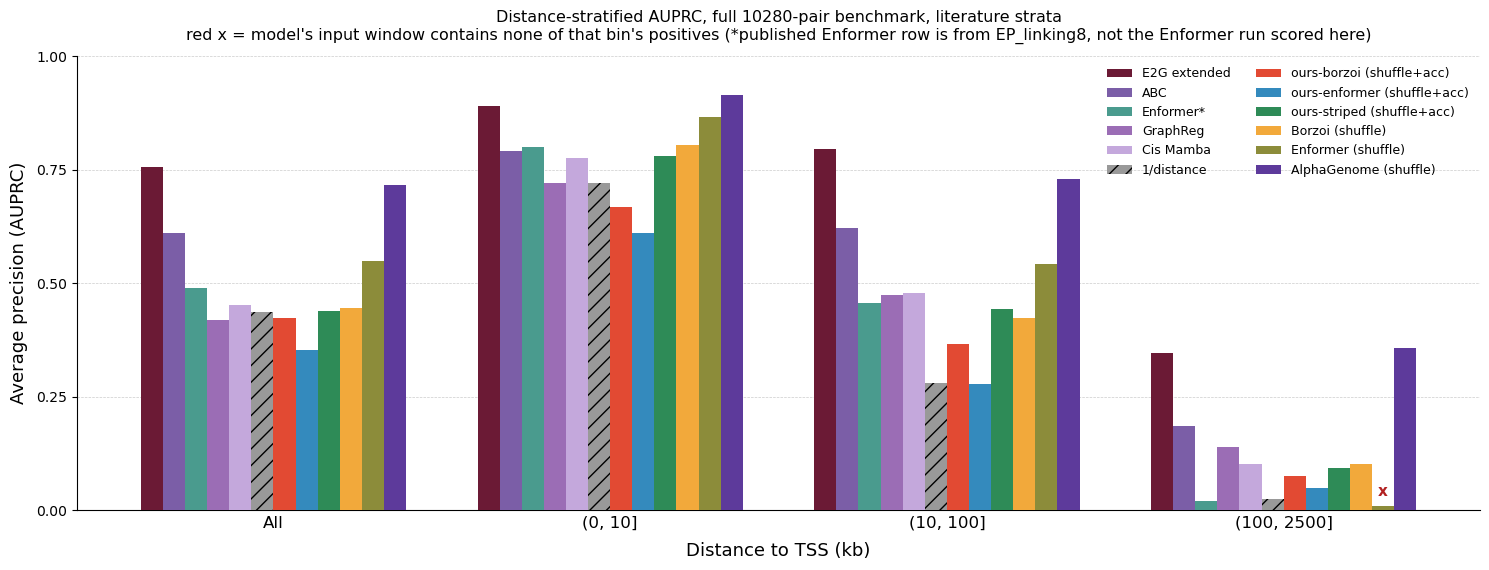

In [26]:
categories2 = [g[0] for g in groups2]
methods2 = list(values_dict2.keys())
colors2 = ["#6B1A35", "#7B5EA7", "#4A9B8E", "#9B6DB5", "#C4A8DC",   #published
           "#999999",                                              #1/distance
           "#E24A33", "#348ABD", "#2E8B57",                         #ours x3
           "#F2A93B", "#8C8C3A", "#5D3A9B"]                         #Borzoi, Enformer, AlphaGenome

bar_width = 0.068
group_spacing = 0.22
x = np.arange(len(categories2)) * (len(methods2) * bar_width + group_spacing)

fig, ax = plt.subplots(figsize=(15, 5.8))
for i, (method, color) in enumerate(zip(methods2, colors2)):
    hatch = '//' if method == '1/distance' else None
    ax.bar(x + i * bar_width, values_dict2[method], width=bar_width, label=method,
           color=color, linewidth=0, zorder=3, hatch=hatch)

#mark the bins a model cannot reach at all, so a baseline-height bar is not read as a result
for i, method in enumerate(methods2):
    m = method.split(' (')[0]
    if m not in MODELS:
        continue
    for j, (_, msk) in enumerate(groups2):
        reachable = int(((y_true_all == 1) & msk & ctx2[(m, 'shuffle')]).sum())
        if reachable == 0 and int((y_true_all[msk] == 1).sum()) > 0:
            ax.text(x[j] + i * bar_width, values_dict2[method][j] + 0.015, 'x',
                    ha='center', va='bottom', fontsize=11, fontweight='bold', color='#B22222')

ax.set_xticks(x + (len(methods2) - 1) * bar_width / 2)
ax.set_xticklabels(categories2, fontsize=12)
ax.set_xlabel("Distance to TSS (kb)", labelpad=8, fontsize=13)
ax.set_ylabel("Average precision (AUPRC)", labelpad=6, fontsize=13)
ax.set_ylim(0, 1.0); ax.set_yticks([0, 0.25, 0.50, 0.75, 1.00])
ax.yaxis.grid(True, linestyle="--", linewidth=0.5, color="#CCCCCC", zorder=0)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.tick_params(axis="x", length=0, pad=4)
ax.legend(frameon=False, fontsize=9, ncol=2, loc="upper right")
ax.set_title("Distance-stratified AUPRC, full 10280-pair benchmark, literature strata\n"
             "red x = model's input window contains none of that bin's positives "
             "(*published Enformer row is from EP_linking8, not the Enformer run scored here)",
             fontsize=11.5, pad=12)
plt.tight_layout(); plt.show()

## Does the perturbation touch the sequence at all?

The three joint models each have all three arms, so the arms answer a question the
published models cannot be asked: how much of the score comes from scaling the
accessibility track down, and how much from destroying the element's motif content.

If `shuffle+acc` is indistinguishable from `acc` alone, the model is reading the
accessibility channel and the sequence in the element is contributing nothing.

,model,N,acc,shuffle,shuffle+acc,shuffle - acc,(shuffle+acc) - acc,"r(acc, shuffle)","r(acc, shuffle+acc)"
0,ours-borzoi,3950,0.4570,0.4324,0.4564,-0.0246,-0.0006,0.7825,0.9786
1,ours-enformer,3950,0.3810,0.3640,0.3793,-0.0170,-0.0017,0.8938,0.9926
2,ours-striped,9732,0.4395,0.3608,0.4430,-0.0787,0.0035,0.3889,0.9846


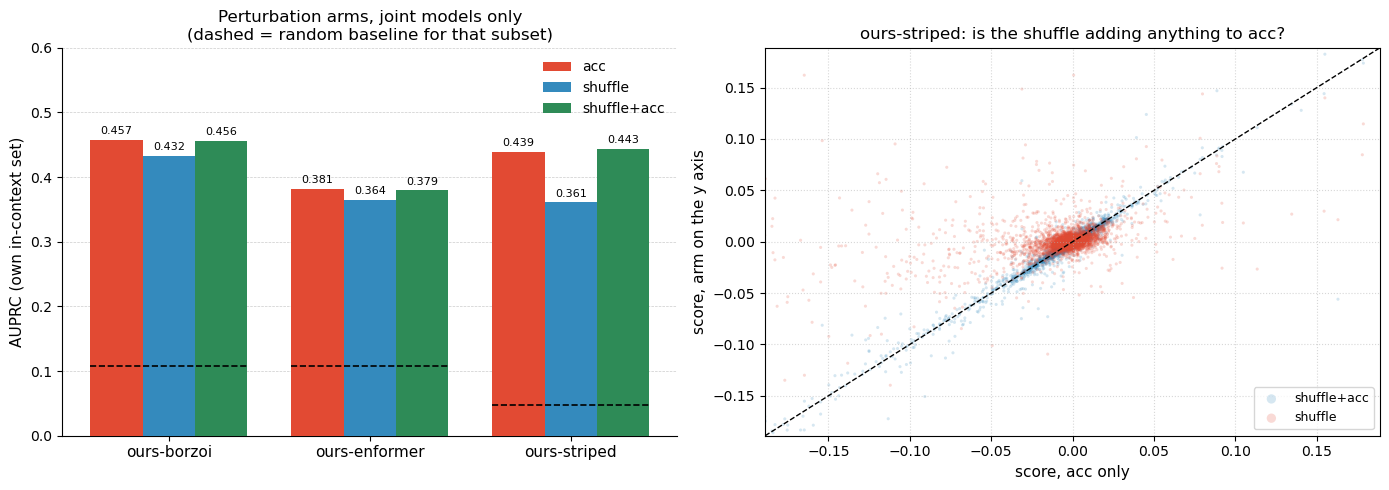

In [27]:
arm_rows = []
for m in ['ours-borzoi', 'ours-enformer', 'ours-striped']:
    own = ctx2[(m, 'acc')]
    r = {'model': m, 'N': int(own.sum())}
    for arm in ARM_ORDER:
        r[arm] = aupr(own, sc2[(m, arm)])
    r['shuffle - acc']       = r['shuffle'] - r['acc']
    r['(shuffle+acc) - acc'] = r['shuffle+acc'] - r['acc']
    #how correlated are the two perturbations' scores, on the pairs they both perturb?
    a, b = sc2[(m, 'acc')][own], sc2[(m, 'shuffle')][own]
    c    = sc2[(m, 'shuffle+acc')][own]
    r['r(acc, shuffle)']       = stats.pearsonr(a, b)[0]
    r['r(acc, shuffle+acc)']   = stats.pearsonr(a, c)[0]
    arm_rows.append(r)
arms_df = pd.DataFrame(arm_rows)
display(arms_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ms = ['ours-borzoi', 'ours-enformer', 'ours-striped']
w = 0.26
xs = np.arange(len(ms))
for j, (arm, col) in enumerate(zip(ARM_ORDER, ['#E24A33', '#348ABD', '#2E8B57'])):
    v = [aupr(ctx2[(m, 'acc')], sc2[(m, arm)]) for m in ms]
    ax.bar(xs + (j - 1) * w, v, width=w, color=col, label=arm, zorder=3)
    for x, vv in zip(xs + (j - 1) * w, v):
        ax.text(x, vv + 0.006, f'{vv:.3f}', ha='center', va='bottom', fontsize=8)
for x, m in zip(xs, ms):
    ax.plot([x - 1.5 * w, x + 1.5 * w], [y_true_all[ctx2[(m, 'acc')]].mean()] * 2,
            color='k', ls='--', lw=1.2, zorder=4)
ax.set_xticks(xs); ax.set_xticklabels(ms, fontsize=11)
ax.set_ylabel('AUPRC (own in-context set)', fontsize=11)
ax.set_title('Perturbation arms, joint models only\n(dashed = random baseline for that subset)', fontsize=12)
ax.set_ylim(0, 0.6)
ax.yaxis.grid(True, ls='--', lw=.5, color='#CCCCCC', zorder=0); ax.set_axisbelow(True)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.legend(frameon=False, fontsize=10)

#and the scatter that makes the redundancy concrete, for the widest-reach joint model
ax = axes[1]
own = ctx2[('ours-striped', 'acc')]
ax.scatter(sc2[('ours-striped', 'acc')][own], sc2[('ours-striped', 'shuffle+acc')][own],
           s=5, alpha=.2, color='#348ABD', edgecolors='none', label='shuffle+acc')
ax.scatter(sc2[('ours-striped', 'acc')][own], sc2[('ours-striped', 'shuffle')][own],
           s=5, alpha=.2, color='#E24A33', edgecolors='none', label='shuffle')
lim = np.percentile(np.abs(sc2[('ours-striped', 'acc')][own]), 99.5)
ax.plot([-lim, lim], [-lim, lim], color='k', lw=1, ls='--')
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.set_xlabel('score, acc only', fontsize=11)
ax.set_ylabel('score, arm on the y axis', fontsize=11)
ax.set_title('ours-striped: is the shuffle adding anything to acc?', fontsize=12)
ax.grid(True, ls=':', alpha=.5)
ax.legend(fontsize=9, markerscale=3)
plt.tight_layout(); plt.show()

## Sensitivity to the TSS window width

Swept in bp so the 32 bp and 128 bp heads are compared over the same physical region.
`shuffle` arm only, AUPRC on the common 1763-pair subset.

model,ours-borzoi,ours-enformer,ours-striped,Borzoi,Enformer,AlphaGenome
half_bp,,,,,,
64,0.4375,0.3968,0.4913,0.5030,0.5652,0.7801
128,0.4378,0.4061,0.5036,0.5104,0.6423,0.7866
288,0.4665,0.4045,0.5045,0.5313,0.6392,0.7947
576,0.4764,0.4062,0.5118,0.5418,0.6562,0.7965
1024,0.4744,0.4037,0.5220,0.5531,0.6685,0.7975
2048,0.4907,0.4112,0.5273,0.5692,0.6680,0.7961


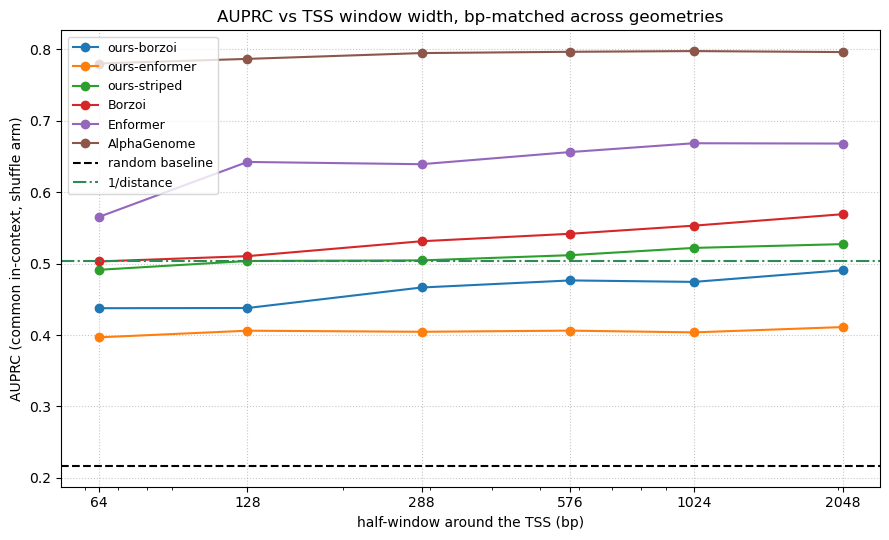

In [28]:
sweep2 = []
for hb in [64, 128, 288, 576, 1024, 2048]:
    for m in MODEL_ORDER:
        k = (m, 'shuffle')
        s = score_slab(slabs[k], ctx2[k], MODELS[m]['bin'], hb)
        sweep2.append(dict(half_bp=hb, model=m, AUPRC=aupr(common_ctx, s),
                           bins=int(round(hb / MODELS[m]['bin']))))
sweep2 = pd.DataFrame(sweep2)
piv2 = sweep2.pivot(index='half_bp', columns='model', values='AUPRC')[MODEL_ORDER]
display(piv2.round(4))

ax = piv2.plot(marker='o', figsize=(9, 5.5))
ax.axhline(y_true_all[common_ctx].mean(), color='k', ls='--', lw=1.5, label='random baseline')
ax.axhline(aupr(common_ctx, dist_score), color='#2E8B57', ls='-.', lw=1.5, label='1/distance')
ax.set_xscale('log')
ax.set_xticks([64, 128, 288, 576, 1024, 2048]); ax.set_xticklabels([64, 128, 288, 576, 1024, 2048])
ax.set_xlabel('half-window around the TSS (bp)'); ax.set_ylabel('AUPRC (common in-context, shuffle arm)')
ax.set_title('AUPRC vs TSS window width, bp-matched across geometries')
ax.grid(True, ls=':', alpha=.7); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

## Did 11 shuffles converge, for every model?

Same statistic as cell 18 - the SEM of the 11 shuffles over the scored window, divided by
the size of the WT-minus-shuffle difference it is trying to resolve - now for all six
`shuffle` arms. A median well below 1 means the shuffle mean is resolved; the second
column is the fraction of pairs where the noise is larger than the effect.

In [29]:
conv_rows = []
for m in MODEL_ORDER:
    k = (m, 'shuffle')
    base = MODELS[m]['arms']['shuffle']
    hb   = int(round(HALF_BP / MODELS[m]['bin']))
    if base.endswith('.zarr'):
        z = zarr.open(E2G + base, mode='r')
        c = z['preds'].shape[-1] // 2
        lo, hi = c - hb, c + hb + 1
        wt  = z['preds'][:, :2, lo:hi].sum((1, 2))
        alt = z['preds'][:, 2:, lo:hi].sum((1, 2))
        sd  = z['shuffle_std'][:, :, lo:hi].sum((1, 2))
    else:
        a  = np.load(E2G + base + '.npy', mmap_mode='r')
        sd_ = np.load(E2G + base + '_shuffle_std.npy', mmap_mode='r')
        c  = a.shape[-1] // 2
        lo, hi = c - hb, c + hb + 1
        nr = a.shape[1]
        if nr == 4:
            wt  = np.asarray(a[:, :2, lo:hi]).sum((1, 2))
            alt = np.asarray(a[:, 2:, lo:hi]).sum((1, 2))
        else:
            wt  = np.asarray(a[:, 0, lo:hi]).sum(1)
            alt = np.asarray(a[:, 1, lo:hi]).sum(1)
        sd = (np.asarray(sd_[:, :, lo:hi]).sum((1, 2)) if sd_.ndim == 3
              else np.asarray(sd_[:, lo:hi]).sum(1))
    sem = sd / np.sqrt(11)
    msk = ctx2[k] & (np.abs(wt - alt) > 0)
    ratio = sem[msk] / np.abs(wt - alt)[msk]
    conv_rows.append(dict(model=m, N=int(msk.sum()), median_SEM_over_effect=np.median(ratio),
                          frac_noise_gt_effect=(ratio > 1).mean(),
                          median_abs_effect=np.median(np.abs(wt - alt)[msk])))
conv_df = pd.DataFrame(conv_rows)
display(conv_df.round(4))

,model,N,median_SEM_over_effect,frac_noise_gt_effect,median_abs_effect
0,ours-borzoi,3947,0.4590,0.2432,0.0055
1,ours-enformer,3950,0.2794,0.1592,0.0170
2,ours-striped,9732,0.4198,0.2341,0.3073
3,Borzoi,3950,0.2596,0.1597,0.1498
4,Enformer,1763,0.2096,0.1174,1.4900
5,AlphaGenome,6624,0.4917,0.2687,15.5664


## Is the extra input window worth anything?

`ours-striped` (2 Mb input) and `AlphaGenome` (1 Mb) can perturb 2674 pairs that Borzoi
and the 524 kb models cannot reach at all. Those pairs are almost all negatives - the
benchmark's positive rate collapses beyond 262 kb - so this is a hard, heavily imbalanced
slice, and the question is only whether the score beats `1/distance` there.

In [30]:
longrange = ctx2[('AlphaGenome', 'shuffle')] & ~reach262
print(f'pairs in AlphaGenome context but beyond the 262 kb reach: {longrange.sum()}, '
      f'positive rate {y_true_all[longrange].mean():.4f}')
lr_rows = [dict(run='1/distance', AUPRC=aupr(longrange, dist_score))]
for k in sc2:
    if MODELS[k[0]]['reach'] > 262144:
        lr_rows.append(dict(run=f'{k[0]} / {k[1]}', AUPRC=aupr(longrange, sc2[k])))
lr_rows.append(dict(run='random', AUPRC=y_true_all[longrange].mean()))
display(pd.DataFrame(lr_rows).round(4))

#and the same on the pairs each of them shares with the 262 kb models, for reference
print('\nfor reference, the same runs on the 262 kb subset:')
display(pd.DataFrame([dict(run=f'{k[0]} / {k[1]}', AUPRC=aupr(reach262, sc2[k]))
                      for k in sc2 if MODELS[k[0]]['reach'] > 262144]).round(4))

pairs in AlphaGenome context but beyond the 262 kb reach: 2674, positive rate 0.0079


,run,AUPRC
0,1/distance,0.0066
1,ours-striped / acc,0.0287
2,ours-striped / shuffle,0.0140
3,ours-striped / shuffle+acc,0.0277
4,AlphaGenome / shuffle,0.1221
5,random,0.0079



for reference, the same runs on the 262 kb subset:


,run,AUPRC
0,ours-striped / acc,0.4970
1,ours-striped / shuffle,0.4281
2,ours-striped / shuffle+acc,0.5004
3,AlphaGenome / shuffle,0.7711


## Direction of the predicted effect, all 15 runs

Cell 24's logic, applied across models. Every `Regulated` pair has `EffectSize < 0`, so
the question is what fraction of them the model also predicts to go down, and crucially
whether that fraction is *higher* than for the non-regulated pairs. A model with a global
downward bias under perturbation scores well on the first number and badly on the gap.

,model,arm,N_reg,frac_down_reg,lo,hi,binom_p,N_notreg,frac_down_notreg,gap
0,ours-borzoi,acc,425,0.5341,0.4866,0.5810,0.0872,3525,0.3104,0.2238
1,ours-borzoi,shuffle,425,0.6000,0.5527,0.6455,0.0000,3525,0.5566,0.0434
2,ours-borzoi,shuffle+acc,425,0.5624,0.5148,0.6088,0.0058,3525,0.3163,0.2460
3,ours-enformer,acc,425,0.6894,0.6439,0.7315,0.0000,3525,0.5149,0.1745
4,ours-enformer,shuffle,425,0.6447,0.5981,0.6887,0.0000,3525,0.7013,-0.0566
5,ours-enformer,shuffle+acc,425,0.6918,0.6463,0.7338,0.0000,3525,0.5299,0.1618
6,ours-striped,acc,458,0.7096,0.6664,0.7493,0.0000,9274,0.5478,0.1618
7,ours-striped,shuffle,458,0.5044,0.4587,0.5499,0.4443,9274,0.4882,0.0161
8,ours-striped,shuffle+acc,458,0.7293,0.6868,0.7679,0.0000,9274,0.5488,0.1804
9,Borzoi,shuffle,425,0.7035,0.6584,0.7450,0.0000,3525,0.5523,0.1512


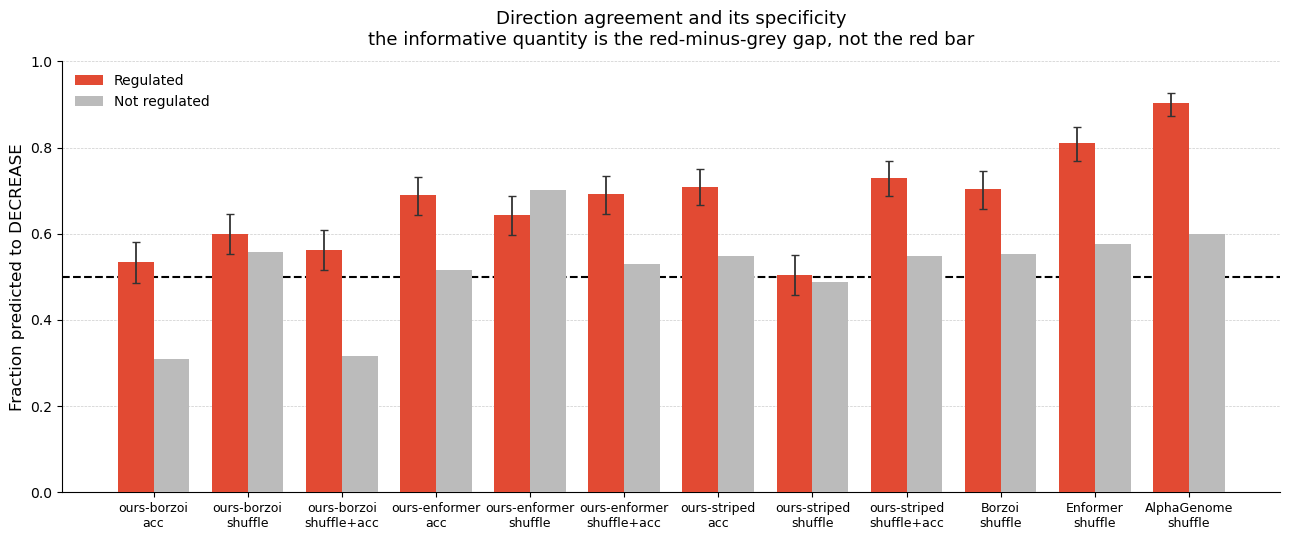

In [31]:
reg_all = gs_df['Regulated'].values.astype(bool)
es_all  = gs_df['EffectSize'].values

dir_rows = []
for k in sc2:
    own = ctx2[k]
    out = {'model': k[0], 'arm': k[1]}
    for lab, sub in [('reg', own & reg_all), ('notreg', own & ~reg_all)]:
        msk = sub & np.isfinite(sc2[k])
        n, nd = int(msk.sum()), int((sc2[k][msk] < 0).sum())
        out[f'N_{lab}'] = n
        out[f'frac_down_{lab}'] = nd / n
        if lab == 'reg':
            lo, hi = wilson(nd, n)
            out['lo'], out['hi'] = lo, hi
            out['binom_p'] = stats.binomtest(nd, n, 0.5, alternative='greater').pvalue
    out['gap'] = out['frac_down_reg'] - out['frac_down_notreg']
    dir_rows.append(out)
dir_df = pd.DataFrame(dir_rows)
display(dir_df[['model', 'arm', 'N_reg', 'frac_down_reg', 'lo', 'hi', 'binom_p',
                'N_notreg', 'frac_down_notreg', 'gap']].round(4))

fig, ax = plt.subplots(figsize=(13, 5.5))
xs = np.arange(len(dir_df))
w = 0.38
for j, (lab, col) in enumerate([('reg', '#E24A33'), ('notreg', '#BBBBBB')]):
    ax.bar(xs + (j - .5) * w, dir_df[f'frac_down_{lab}'], width=w, color=col, zorder=3,
           label={'reg': 'Regulated', 'notreg': 'Not regulated'}[lab])
err = np.vstack([dir_df['frac_down_reg'] - dir_df['lo'], dir_df['hi'] - dir_df['frac_down_reg']])
ax.errorbar(xs - .5 * w, dir_df['frac_down_reg'], yerr=err, fmt='none', ecolor='#333333',
            lw=1.3, capsize=3, zorder=4)
ax.axhline(0.5, color='k', ls='--', lw=1.5, zorder=2)
ax.set_xticks(xs)
ax.set_xticklabels([f'{m}\n{a}' for m, a in zip(dir_df['model'], dir_df['arm'])], fontsize=9)
ax.set_ylabel('Fraction predicted to DECREASE', fontsize=12)
ax.set_ylim(0, 1.0)
ax.set_title('Direction agreement and its specificity\n'
             'the informative quantity is the red-minus-grey gap, not the red bar', fontsize=13, pad=12)
ax.yaxis.grid(True, ls='--', lw=.5, color='#CCCCCC', zorder=0); ax.set_axisbelow(True)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.legend(frameon=False, fontsize=10, loc='upper left')
plt.tight_layout(); plt.show()

## Correlation with measured effect size

On the `Regulated` pairs only, where `EffectSize` actually varies. A model that has the
magnitude right, not just the sign, should show a **positive** Pearson correlation here:
`EffectSize` is negative and more negative for stronger enhancers, and the score is
negative for a predicted decrease, so a stronger enhancer means a more negative score and
a more negative measured effect.

,model,arm,N,pearson,pearson_p,spearman,spearman_p
0,ours-borzoi,acc,425,-0.0330,0.4978,0.0098,0.8411
1,ours-borzoi,shuffle,425,-0.0665,0.1711,0.0145,0.7654
2,ours-borzoi,shuffle+acc,425,-0.0341,0.4831,0.0198,0.6841
3,ours-enformer,acc,425,-0.0723,0.1369,0.0039,0.9354
4,ours-enformer,shuffle,425,-0.0747,0.1242,-0.0609,0.2104
5,ours-enformer,shuffle+acc,425,-0.0738,0.1286,-0.0104,0.8313
6,ours-striped,acc,458,-0.1075,0.0214,-0.0977,0.0367
7,ours-striped,shuffle,458,-0.0137,0.7693,-0.0287,0.5402
8,ours-striped,shuffle+acc,458,-0.1055,0.0240,-0.0927,0.0473
9,Borzoi,shuffle,425,0.1632,0.0007,0.0345,0.4782


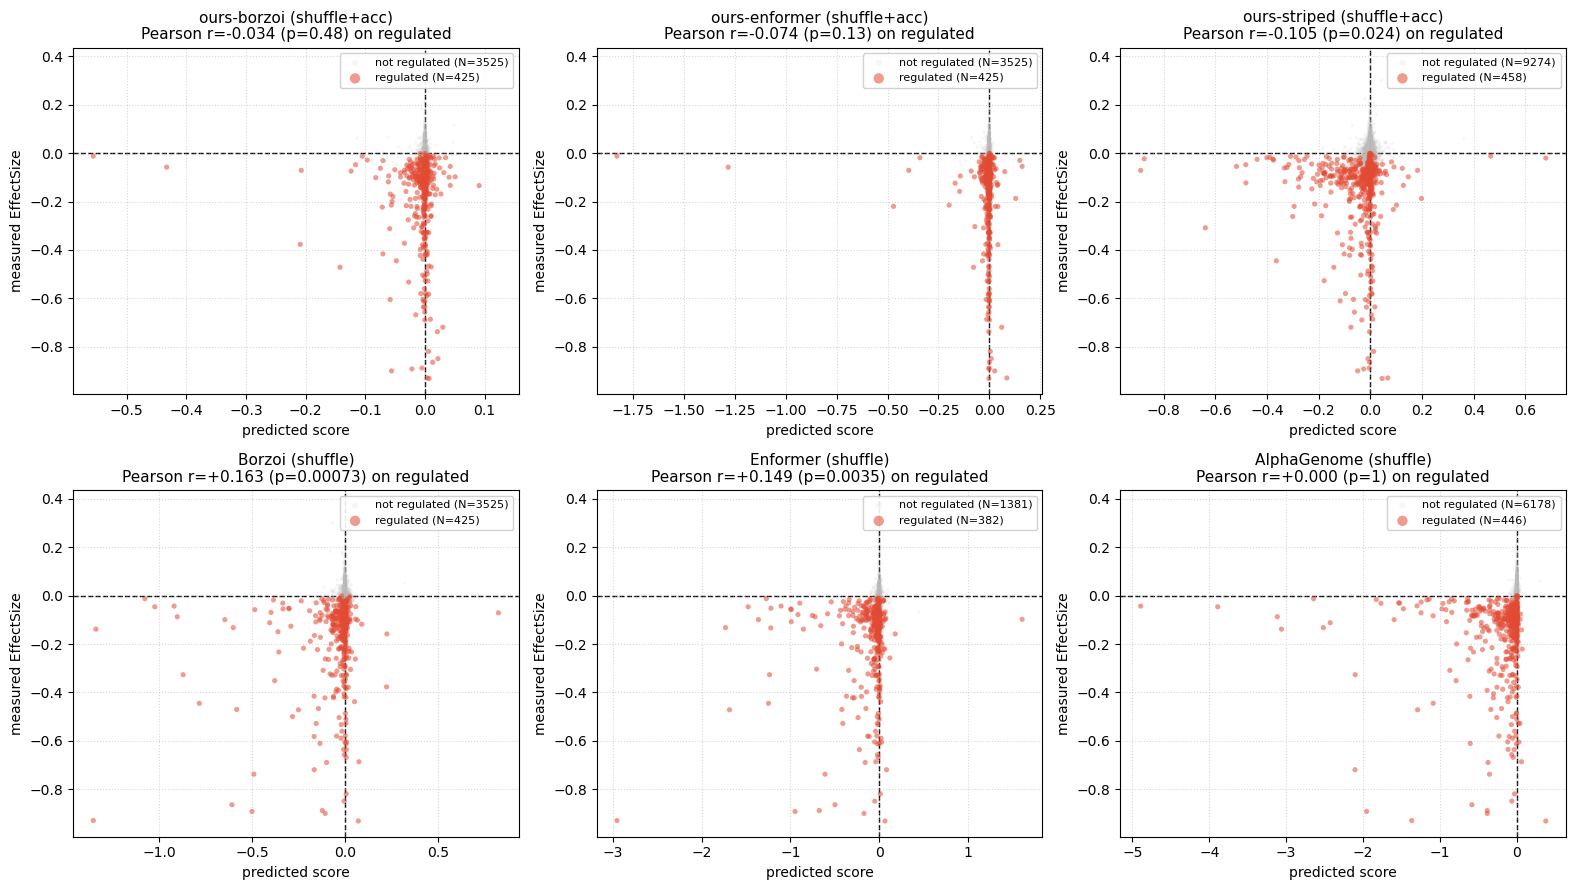

In [32]:
corr_rows = []
for k in sc2:
    msk = ctx2[k] & reg_all & np.isfinite(sc2[k]) & np.isfinite(es_all)
    r, p   = stats.pearsonr(sc2[k][msk], es_all[msk])
    rho, q = stats.spearmanr(sc2[k][msk], es_all[msk])
    corr_rows.append(dict(model=k[0], arm=k[1], N=int(msk.sum()),
                          pearson=r, pearson_p=p, spearman=rho, spearman_p=q))
display(pd.DataFrame(corr_rows).round(4))

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, m in zip(axes.flat, MODEL_ORDER):
    arm = BEST_ARM.get(m, 'shuffle')
    k = (m, arm)
    mr = ctx2[k] & reg_all & np.isfinite(sc2[k]) & np.isfinite(es_all)
    mn = ctx2[k] & ~reg_all & np.isfinite(sc2[k]) & np.isfinite(es_all)
    ax.scatter(sc2[k][mn], es_all[mn], s=5, alpha=.12, color='#BBBBBB', edgecolors='none',
               label=f'not regulated (N={mn.sum()})', zorder=2)
    ax.scatter(sc2[k][mr], es_all[mr], s=14, alpha=.55, color='#E24A33', edgecolors='none',
               label=f'regulated (N={mr.sum()})', zorder=3)
    ax.axvline(0, color='k', lw=1, ls='--', zorder=1); ax.axhline(0, color='k', lw=1, ls='--', zorder=1)
    r, p = stats.pearsonr(sc2[k][mr], es_all[mr])
    ax.set_title(f'{m} ({arm})\nPearson r={r:+.3f} (p={p:.2g}) on regulated', fontsize=11)
    ax.set_xlabel('predicted score', fontsize=10); ax.set_ylabel('measured EffectSize', fontsize=10)
    ax.grid(True, ls=':', alpha=.5)
    ax.legend(fontsize=8, loc='upper right', framealpha=.9, markerscale=2)
plt.tight_layout(); plt.show()

## What Part 2 says

Read off the tables above. All AUPRC values are `average_precision_score`; subsets are named
explicitly because `in_context` differs between models.

**Ranking, common 1763 pairs** (random 0.217, `1/distance` 0.502): AlphaGenome ~0.80 >>
Enformer ~0.66 > ours-striped ~0.57 > Borzoi ~0.54 > ours-borzoi ~0.49 > ours-enformer ~0.42.
On the 262 kb subset (`1/distance` 0.467): AlphaGenome ~0.77 >> ours-striped ~0.50 ~
Borzoi ~0.48 ~ ours-borzoi ~0.46 > ours-enformer ~0.38.

**Against the published methods, on the literature's own strata (full benchmark).**
E2G-extended 0.756 / 0.89 / 0.795 / 0.346 for All / (0,10] / (10,100] / (100,2500].
AlphaGenome 0.715 / 0.915 / 0.729 / 0.357. So AlphaGenome is the best of the sequence
models by a wide margin, is the best of anything in the proximal bin, and is **level with
E2G-extended at distal and slightly below it elsewhere** - it does not beat E2G. Our models
land at 0.42-0.44 overall and 0.05-0.09 distal, i.e. below ABC (0.610 / 0.186) and below
`1/distance` overall (0.436).

**Concern 1 - most of our runs do not beat `1/distance`.** On the 262 kb subset ours-borzoi
(0.46) and ours-enformer (0.38) are at or below the distance baseline and ours-striped clears
it by ~0.03. The one place our models clearly beat distance is the distal bin (0.07-0.09 vs
0.025), which is the bin where distance carries least information.

**Concern 2 - the sequence perturbation is contributing almost nothing to our joint models.**
For all three, `acc` ~ `shuffle+acc` > `shuffle`, and `shuffle+acc` is nearly collinear with
`acc`. Scaling accessibility down 100x does the work; destroying the element's motif content
on top moves AUPRC by <0.01, and `shuffle` alone is the worst arm. Sharpest case:
`ours-striped/shuffle` is at chance on the direction test (50.4% predicted down on regulated
pairs, p=0.44) while `acc` is at 71.0%. The sequence-only published models do fine on
shuffling alone, so this points at the joint models leaning on the accessibility channel
rather than reading the element's sequence.

**Concern 3 - direction specificity is weak, and one arm is inverted.** The
regulated-minus-not-regulated gap is +0.30 for AlphaGenome and +0.24 for Enformer, but +0.02
for `ours-striped/shuffle` and **-0.06** for `ours-enformer/shuffle`, which predicts a
decrease *more* often for non-regulated pairs. The high raw "fraction predicted down" for the
shuffle arms (0.60-0.70) is a global downward bias of dinucleotide shuffling, not
enhancer-specific signal.

**Concern 4 - effect-size correlation has the wrong sign for our models.** Borzoi (r=+0.16)
and Enformer (r=+0.15) correlate positively with `EffectSize` on regulated pairs, as they
should. All of our arms are weakly *negative* (-0.01 to -0.11), and the only nominally
significant ones (`ours-striped` acc arms, p~0.02) are significant in the wrong direction.
AlphaGenome is flat (r=0.000), so magnitude calibration is hard for everyone, but a
consistently negative sign in our runs is worth chasing.

**Metric caveat, and it is not cosmetic.** The `auc(recall, precision)` convention inherited
from `EP_linking4`/`EP_linking8` linearly interpolates across tied scores and returns
~`(baseline+1)/2` when a stratum is entirely tied. Because out-of-window pairs are assigned
score 0, that convention reports 0.505 for the pretrained Enformer beyond 100 kb, where it
can reach none of the 81 positives - a pure artifact. Part 1's numbers are unaffected in
practice (its runs share one `in_context` set, and AP differs from the trapezoid by <0.005
there), but the Part 1 cells would need the same switch before any of those numbers goes into
a figure.

**Shuffle convergence is adequate but not generous.** Median SEM over effect is 0.21-0.26 for
the pretrained sequence models and 0.42-0.49 for `ours-striped`, `ours-borzoi` and
AlphaGenome, with 16-27% of pairs where the shuffle noise exceeds the effect. 11 shuffles
resolve the mean for most pairs; the noisier arms would benefit from more.

**The extra input window buys little for us, something for AlphaGenome.** Beyond 262 kb the
benchmark is 2674 pairs at a 0.8% positive rate. AlphaGenome gets real signal there;
`ours-striped` gets a few times the distance baseline off ~21 positives, which is close to
noise. The 2 Mb input is not yet paying for itself on this benchmark.

**The window width is not driving anything.** The bp sweep is flat-to-slowly-rising from
64 bp to 2048 bp with a stable ranking, so no conclusion hangs on the 576 bp choice
inherited from `EP_linking4`.

**Provenance caveat on every comparison to a published method.** The E2G/ABC/GraphReg/Cis
Mamba bars are hardcoded from `EP_linking8` without a citation or a stated metric and were
not recomputed on these 10280 pairs, so the "level with E2G-extended" reading above is only
as good as that row. AlphaGenome's own paper reports the same parity with rE2G-extended
("within 1% auPRC", zero-shot, bioRxiv 2025.06.25.661532 / Nature s41586-025-10014-0
Fig. 4j), which is reassuring, but the right fix is to score published rE2G-extended and ABC
predictions on these pairs directly with `aupr`.